In [1]:
import numpy as np
from SALib.sample import saltelli
from SALib.analyze import sobol
from SALib.sample import morris as morris_sample
from SALib.analyze import morris as morris_analyze
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import json
import pandas as pd
import csv
from copy import deepcopy

final_plot_data = {}

final_plot_data_stability = {}


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore


# No AS generate input

In [ ]:
# define names
with open("../../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

print(parameters_input.keys())
names1 = list(parameters_input["chambers"].keys())
names2 = list(parameters_input["valves"].keys())
names3 = list(parameters_input["circulation"].keys())
names4 = ['Ra_LAD', 'Ra_LCX', 'Ra_RCA', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Rv_LAD', 'Rv_LCX', 'Rv_RCA', 'Ca_LAD', 'Ca_LCX', 'Ca_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor']
names5 = list(parameters_input["initial_conditions"].keys())
names = names1 + names2 + names3 + names4 + names5
print(names)
parameters_count = len(names)
print(f"Number of parameters: {parameters_count}")

# define bounds
# names1
Emax_ra_bounds = [0.17, 0.5]
Emin_ra_bounds = [0.01, 0.16]
m1_ra_bounds = [1.0, 10]
m2_ra_bounds = [5, 20]
V0ra_bounds = [-50, 30]
Emax_rv_bounds = [0.3, 1.2] 
Emin_rv_bounds = [0.01, 0.25]
m1_rv_bounds = [1.0, 10]
m2_rv_bounds = [10, 50]
V0rv_bounds = [-50, 80]
Emax_la_bounds = [0.14, 0.5]
Emin_la_bounds = [0.05, 0.13]
m1_la_bounds = [1.0, 10]
m2_la_bounds = [5, 20]
V0la_bounds = [-50, 70]
Emax_lv_bounds = [1, 4]
Emin_lv_bounds = [0.01, 0.8]
m1_lv_bounds = [1.0, 10]
m2_lv_bounds = [10, 50]
V0lv_bounds = [-50, 50]
bounds = [Emax_ra_bounds, Emin_ra_bounds, m1_ra_bounds, m2_ra_bounds, V0ra_bounds,
          Emax_rv_bounds, Emin_rv_bounds, m1_rv_bounds, m2_rv_bounds, V0rv_bounds,
          Emax_la_bounds, Emin_la_bounds, m1_la_bounds, m2_la_bounds, V0la_bounds,
          Emax_lv_bounds, Emin_lv_bounds, m1_lv_bounds, m2_lv_bounds, V0lv_bounds]

# names2
Amax_tv_bounds = [4.0, 5.0]
Amin_tv_bounds = [1e-06, 1e-05]
Kvo_tv_bounds = [0.003, 0.3]
Kvc_tv_bounds = [0.004, 0.4]
Amax_pv_bounds = [4.0, 5.0]
Amin_pv_bounds = [1e-06, 1e-05]
Kvo_pv_bounds = [0.002, 0.2]
Kvc_pv_bounds = [0.002, 0.2]
Amax_mv_bounds = [4.0, 5.0]
Amin_mv_bounds = [1e-06, 1e-05]
Kvo_mv_bounds = [0.003, 0.3]
Kvc_mv_bounds = [0.004, 0.4]
Amax_av_bounds = [3.0, 4.0]
Amin_av_bounds = [1e-06, 1e-05]
Kvo_av_bounds = [0.0012, 0.12]
Kvc_av_bounds = [0.0012, 0.12]
bounds += [
    Amax_tv_bounds, Amin_tv_bounds, Kvo_tv_bounds, Kvc_tv_bounds,
    Amax_pv_bounds, Amin_pv_bounds, Kvo_pv_bounds, Kvc_pv_bounds,
    Amax_mv_bounds, Amin_mv_bounds, Kvo_mv_bounds, Kvc_mv_bounds,
    Amax_av_bounds, Amin_av_bounds, Kvo_av_bounds, Kvc_av_bounds
]

# names3
HR_bounds = [40, 180]
density_bounds = [0.9, 1.3]
Rao_bounds = [0.01, 0.1]
Ca_syst_bounds = [0.5, 5]
Ra_syst_bounds = [0.1, 3]
Cv_syst_bounds = [10, 150]
Rv_syst_bounds = [0.01, 0.2]
Rpa_bounds = [0.001, 0.1]
Ca_pulm_bounds = [1, 10]
Ra_pulm_bounds = [0.01, 1]
Cv_pulm_bounds = [5, 50]
Rv_pulm_bounds = [0.0005, 0.05]
bounds += [
    HR_bounds, density_bounds, Rao_bounds, Ca_syst_bounds, Ra_syst_bounds, Cv_syst_bounds, Rv_syst_bounds,
    Rpa_bounds, Ca_pulm_bounds, Ra_pulm_bounds, Cv_pulm_bounds, Rv_pulm_bounds
]

# names4
Ra_LAD_bounds = [0.1, 10]
Ra_LCX_bounds = [0.1, 10]
Ra_RCA_bounds = [0.1, 10]
Rmicro_max_LAD_bounds = [43, 170]
#Rmicro_min_LAD_bounds = [25, 42]
Rmicro_max_LCX_bounds = [52, 170]
#Rmicro_min_LCX_bounds = [22, 51]
Rmicro_max_RCA_bounds = [59, 170]
#Rmicro_min_RCA_bounds = [28, 58]
Rv_LAD_bounds = [0.1, 10]
Rv_LCX_bounds = [0.1, 10]
Rv_RCA_bounds = [0.1, 10]
Ca_LAD_bounds = [0.001, 0.2]
Ca_LCX_bounds = [0.001, 0.2]
Ca_RCA_bounds = [0.001, 0.2]
Cmicro_LAD_bounds = [0.05, 2]
Cmicro_LCX_bounds = [0.05, 2]
Cmicro_RCA_bounds = [0.05, 2]
hypertrophy_factor_bounds = [1.0, 3.0]
bounds += [
    Ra_LAD_bounds, Ra_LCX_bounds, Ra_RCA_bounds,
    Rmicro_max_LAD_bounds, Rmicro_max_LCX_bounds, Rmicro_max_RCA_bounds,
    Rv_LAD_bounds, Rv_LCX_bounds, Rv_RCA_bounds, Ca_LAD_bounds, Ca_LCX_bounds, Ca_RCA_bounds,
    Cmicro_LAD_bounds, Cmicro_LCX_bounds, Cmicro_RCA_bounds, hypertrophy_factor_bounds
]

# names5
icVra_bounds = [10, 100]
icVrv_bounds = [85, 250]
icVla_bounds = [10, 100]
icVlv_bounds = [75, 250]
icQtv_bounds = [0, 1]
icQpv_bounds = [0, 1]
icQmv_bounds = [0, 1]
icQav_bounds = [0, 1]
iceps_tv_bounds = [0, 1]
iceps_pv_bounds = [0, 1]
iceps_mv_bounds = [0, 1]
iceps_av_bounds = [0, 1]
icPa_syst_bounds = [30, 140]
icPv_syst_bounds = [2, 50]
icPa_pulm_bounds = [5, 20]
icPv_pulm_bounds = [1, 14]
icPa_LAD_bounds = [40, 60]
icPv_LAD_bounds = [10, 18]
icPa_LCX_bounds = [40, 60]
icPv_LCX_bounds = [10, 18]
icPa_RCA_bounds = [40, 60]
icPv_RCA_bounds = [10, 18]
bounds += [
    icVra_bounds, icVrv_bounds, icVla_bounds, icVlv_bounds,
    icQtv_bounds, icQpv_bounds, icQmv_bounds, icQav_bounds,
    iceps_tv_bounds, iceps_pv_bounds, iceps_mv_bounds, iceps_av_bounds,
    icPa_syst_bounds, icPv_syst_bounds, icPa_pulm_bounds, icPv_pulm_bounds,
    icPa_LAD_bounds, icPv_LAD_bounds, icPa_LCX_bounds, icPv_LCX_bounds,
    icPa_RCA_bounds, icPv_RCA_bounds
]

print(bounds)
print(f"Bounds len: {len(bounds)}, expected len: {parameters_count}")






dict_keys(['chambers', 'valves', 'circulation', 'CBF_model', 'initial_conditions'])
['Emax_ra', 'Emin_ra', 'm1_ra', 'm2_ra', 'V0ra', 'Emax_rv', 'Emin_rv', 'm1_rv', 'm2_rv', 'V0rv', 'Emax_la', 'Emin_la', 'm1_la', 'm2_la', 'V0la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'm2_lv', 'V0lv', 'Amax_tv', 'Amin_tv', 'Kvo_tv', 'Kvc_tv', 'Amax_pv', 'Amin_pv', 'Kvo_pv', 'Kvc_pv', 'Amax_mv', 'Amin_mv', 'Kvo_mv', 'Kvc_mv', 'Amax_av', 'Amin_av', 'Kvo_av', 'Kvc_av', 'HR', 'density', 'Rao', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rpa', 'Ca_pulm', 'Ra_pulm', 'Cv_pulm', 'Rv_pulm', 'Ra_LAD', 'Ra_LCX', 'Ra_RCA', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Rv_LAD', 'Rv_LCX', 'Rv_RCA', 'Ca_LAD', 'Ca_LCX', 'Ca_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor', 'icVra', 'icVrv', 'icVla', 'icVlv', 'icQtv', 'icQpv', 'icQmv', 'icQav', 'iceps_tv', 'iceps_pv', 'iceps_mv', 'iceps_av', 'icPa_syst', 'icPv_syst', 'icPa_pulm', 'icPv_pulm', 'icPa_LAD', 'icPv_LAD', 'icPa_LCX', 'icPv_LCX', 'icPa_RC

In [ ]:
# Generate Dataset

problem = {
    "num_vars": parameters_count,
    "names": names,
    "bounds": bounds
}

N_trajectories = 1000
N_optimal_trajectories = 80
X = morris_sample.sample(problem, N=N_trajectories, num_levels=4, optimal_trajectories=N_optimal_trajectories, local_optimization=True)
print(f"Generated {X.shape[0]} parameter sets for Morris screening.")
print(X)

input_data = {}
for i in range(len(names)):
    input_data[names[i]] = X[:,i]

df = pd.DataFrame(input_data)
df.to_csv("Data/morris_input_data_allparams_noAS.csv", index=False)



# No AS Analyse results

In [2]:
# morris analysis for noAS

output_df_noAS = pd.read_csv("Data/morris_output_data_noAS.csv")


output_df_noAS_notstability = output_df_noAS[output_df_noAS["stability_reached"] == 0]
output_df_noAS_stable = output_df_noAS[output_df_noAS["stability_reached"] == 1]
output_df_noAS_notstability_indexes = output_df_noAS_notstability.index.tolist()
print(f"Number of samples with stability issues: {len(output_df_noAS_notstability)} out of {len(output_df_noAS)}")
print(output_df_noAS_notstability_indexes)

input_df_noAS = pd.read_csv("Data/morris_input_data_allparams_noAS.csv")
input_df_noAS_notstability = input_df_noAS.iloc[output_df_noAS_notstability_indexes]
#input_df_noAS_notstability.to_csv("Data/morris_input_data_noAS_notstability.csv", index=False)

output_df_noAS_stable.describe()




Number of samples with stability issues: 517 out of 6960
[23, 24, 25, 26, 27, 28, 29, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 254, 259, 286, 295, 296, 297, 298, 299, 300, 301, 302, 303, 304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316, 317, 610, 611, 728, 729, 730, 731, 732, 1103, 1212, 1213, 1276, 1277, 1278, 1279, 1280, 1281, 1282, 1283, 1284, 1285, 1286, 1287, 1288, 1289, 1290, 1291, 1292, 1293, 1294, 1295, 1296, 1297, 1298, 1299, 1300, 1301, 1302, 1303, 1588, 1589, 1653, 1654, 1655, 1656, 1657, 1658, 1659, 1660, 1661, 1662, 1663, 1664, 1665, 1666, 1667, 1668, 1669, 1670, 1671, 1672, 1673, 1674, 1675, 1676, 1677, 1678, 1679, 1680, 1681, 1682, 1683, 1684, 1685, 1686, 1687, 1688, 1689, 1690, 1691, 1692, 1693, 1694, 1695, 1696, 1697, 1698, 1699, 1700, 1701, 1702, 1703, 1704, 1778, 1779, 1780, 1785, 1786, 1787, 1788, 1789, 1792, 1793, 1859, 1860, 1861, 1862, 1863, 1864, 1865, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923, 19

,stability_reached,stability_reached_cycle,Pao_max,Pao_min,Pao_mean,Ppt_max,Ppt_min,Ppt_mean,Pa_syst_max,Pa_syst_min,...,CO_lv,RVET,LVET,Ees_rv,Ees_lv,Ea_rv,Ea_lv,VAC_rv,VAC_lv,DeltaE
count,6443.0,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,...,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000,6443.000000
mean,1.0,96.697812,122.077608,82.614517,96.148575,86.303430,38.374630,53.496244,105.823353,83.849951,...,3786.077246,0.294577,0.373352,0.511618,2.317536,1.825984,3.419118,5.214710,2.219028,-1.301668
std,0.0,63.252936,124.759333,95.738451,105.856055,77.626507,38.848754,47.121928,113.066904,97.389066,...,3570.969579,0.356638,0.441319,0.307369,1.245072,1.721372,2.898793,6.805541,2.677100,12.036918
min,1.0,13.000000,5.930805,2.563965,4.297700,6.107167,-21.519916,3.724103,4.102344,2.907789,...,53.483288,0.035518,0.038019,0.013786,0.117554,0.025131,0.125001,0.047719,0.029408,-155.332165
25%,1.0,52.000000,36.945393,19.884188,26.103723,31.542121,12.404424,20.561061,31.496035,20.149307,...,1312.117941,0.093380,0.083067,0.263715,0.974548,0.737068,1.106909,1.488142,0.570357,-1.646956
50%,1.0,82.000000,78.936292,46.301179,57.891665,58.542507,27.166359,38.238293,64.517697,48.057269,...,2693.490943,0.152576,0.165233,0.424658,2.388406,1.403747,2.672196,3.121632,1.184503,-0.367691
75%,1.0,122.000000,161.751392,114.709571,130.704635,122.726472,48.853010,70.794332,140.630182,116.822906,...,5048.166044,0.333333,0.450000,0.750713,3.529897,2.463570,5.292126,6.573666,2.792801,1.698991
max,1.0,449.000000,1018.994835,786.485390,843.873429,585.940807,267.720480,332.347063,833.021352,801.151226,...,37841.309032,1.500000,1.500000,2.157473,6.723231,34.210652,60.772559,134.286374,52.350288,61.143481


X shape: (6960, 86)
Dropping trajectories 33 out of 80: {0, 2, 3, 7, 8, 12, 13, 14, 18, 19, 20, 21, 22, 27, 30, 32, 34, 35, 36, 37, 41, 43, 46, 47, 50, 53, 54, 58, 59, 61, 62, 69, 77}

--- Morris Screening Results for Output Pa_syst_mean ---
Ra_syst: mu* = 0.6396, sigma = 0.5155         | Ra_syst: mu* = 0.6396, sigma = 0.5155
icPv_syst: mu* = 0.4392, sigma = 0.3477       | Cv_syst: mu* = 0.2614, sigma = 0.3648
Emin_lv: mu* = 0.2796, sigma = 0.2723         | icPv_syst: mu* = 0.4392, sigma = 0.3477
Cv_syst: mu* = 0.2614, sigma = 0.3648         | Emax_lv: mu* = 0.1710, sigma = 0.2949
Emax_lv: mu* = 0.1710, sigma = 0.2949         | Emin_lv: mu* = 0.2796, sigma = 0.2723
Emin_rv: mu* = 0.1329, sigma = 0.2210         | Emin_rv: mu* = 0.1329, sigma = 0.2210
Ra_pulm: mu* = 0.1242, sigma = 0.1583         | Emin_ra: mu* = 0.0772, sigma = 0.1844
HR: mu* = 0.1035, sigma = 0.1288              | Ra_pulm: mu* = 0.1242, sigma = 0.1583
Cv_pulm: mu* = 0.1017, sigma = 0.1466         | Rv_syst: mu* = 0.081

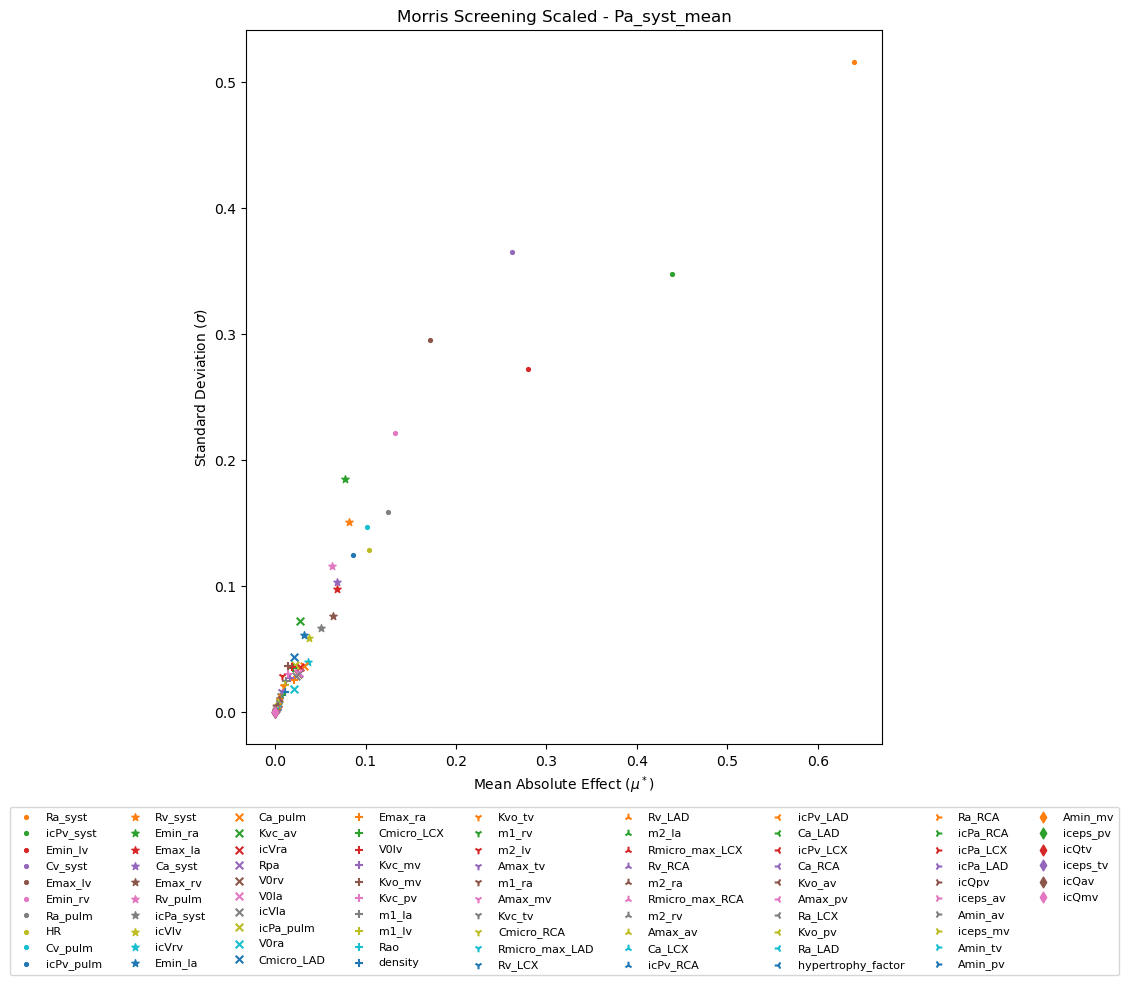


--- Morris Screening Results for Output VO2_total ---
icPv_syst: mu* = 0.6126, sigma = 0.4506       | Cv_syst: mu* = 0.3538, sigma = 0.5430
Cv_syst: mu* = 0.3538, sigma = 0.5430         | icPv_syst: mu* = 0.6126, sigma = 0.4506
Emin_lv: mu* = 0.3335, sigma = 0.3185         | Emin_rv: mu* = 0.2913, sigma = 0.3601
Emin_rv: mu* = 0.2913, sigma = 0.3601         | Emin_lv: mu* = 0.3335, sigma = 0.3185
Ra_syst: mu* = 0.1984, sigma = 0.2653         | Rv_syst: mu* = 0.1508, sigma = 0.2716
HR: mu* = 0.1719, sigma = 0.2307              | Ra_syst: mu* = 0.1984, sigma = 0.2653
Rv_syst: mu* = 0.1508, sigma = 0.2716         | Ra_pulm: mu* = 0.1344, sigma = 0.2442
Ra_pulm: mu* = 0.1344, sigma = 0.2442         | Ca_syst: mu* = 0.1179, sigma = 0.2417
Cv_pulm: mu* = 0.1264, sigma = 0.1881         | HR: mu* = 0.1719, sigma = 0.2307
Ca_syst: mu* = 0.1179, sigma = 0.2417         | Cv_pulm: mu* = 0.1264, sigma = 0.1881
icPv_pulm: mu* = 0.0937, sigma = 0.1105       | Emin_ra: mu* = 0.0871, sigma = 0.1544
Em

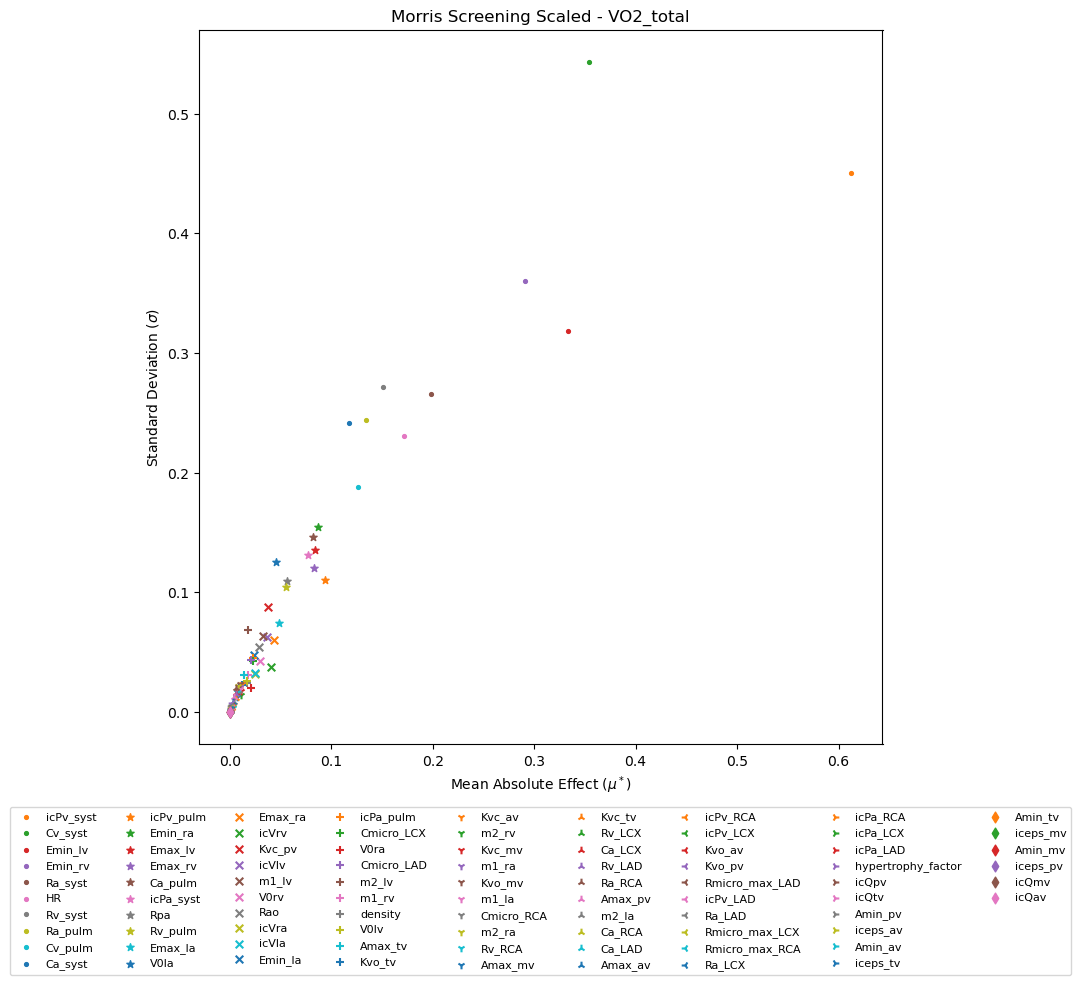


--- Morris Screening Results for Output Ein ---
Ra_syst: mu* = 0.5673, sigma = 0.4533         | Ra_syst: mu* = 0.5673, sigma = 0.4533
HR: mu* = 0.4518, sigma = 0.4266              | HR: mu* = 0.4518, sigma = 0.4266
icPv_syst: mu* = 0.3807, sigma = 0.3735       | icPv_syst: mu* = 0.3807, sigma = 0.3735
Emin_lv: mu* = 0.2784, sigma = 0.3533         | Emin_lv: mu* = 0.2784, sigma = 0.3533
Cv_syst: mu* = 0.2038, sigma = 0.3091         | Cv_syst: mu* = 0.2038, sigma = 0.3091
Emin_rv: mu* = 0.1821, sigma = 0.2163         | Emin_rv: mu* = 0.1821, sigma = 0.2163
Ra_pulm: mu* = 0.1373, sigma = 0.1945         | Ra_pulm: mu* = 0.1373, sigma = 0.1945
Emax_lv: mu* = 0.1218, sigma = 0.1892         | Emax_lv: mu* = 0.1218, sigma = 0.1892
Rmicro_max_LAD: mu* = 0.1166, sigma = 0.1099  | Emin_ra: mu* = 0.0826, sigma = 0.1521
Rmicro_max_LCX: mu* = 0.1079, sigma = 0.0998  | Rv_syst: mu* = 0.0755, sigma = 0.1357
Emax_rv: mu* = 0.0864, sigma = 0.0821         | Rv_pulm: mu* = 0.0619, sigma = 0.1303
Cv_pulm:

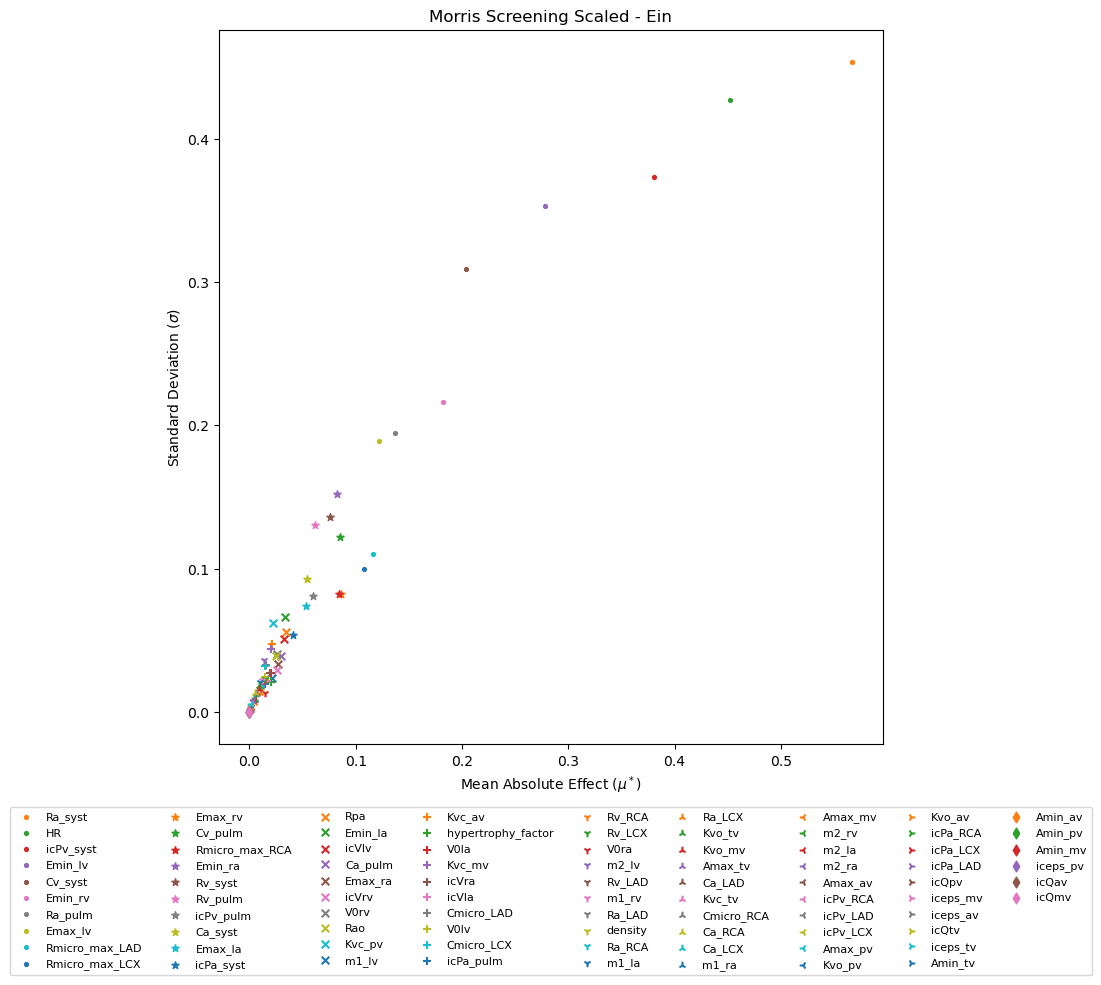


--- Morris Screening Results for Output CO_lv ---
icPv_syst: mu* = 0.6096, sigma = 0.3850       | Cv_syst: mu* = 0.3033, sigma = 0.4057
Emin_lv: mu* = 0.3547, sigma = 0.2833         | icPv_syst: mu* = 0.6096, sigma = 0.3850
Ra_syst: mu* = 0.3075, sigma = 0.2808         | Emin_lv: mu* = 0.3547, sigma = 0.2833
Cv_syst: mu* = 0.3033, sigma = 0.4057         | Ra_syst: mu* = 0.3075, sigma = 0.2808
Emin_rv: mu* = 0.2115, sigma = 0.1819         | Rv_syst: mu* = 0.1747, sigma = 0.2004
Ra_pulm: mu* = 0.2070, sigma = 0.1963         | Ra_pulm: mu* = 0.2070, sigma = 0.1963
Rv_syst: mu* = 0.1747, sigma = 0.2004         | Emin_rv: mu* = 0.2115, sigma = 0.1819
HR: mu* = 0.1695, sigma = 0.1493              | Ca_syst: mu* = 0.1002, sigma = 0.1797
Emax_rv: mu* = 0.1661, sigma = 0.1731         | Cv_pulm: mu* = 0.1273, sigma = 0.1739
Emax_lv: mu* = 0.1345, sigma = 0.1339         | Emax_rv: mu* = 0.1661, sigma = 0.1731
Emin_ra: mu* = 0.1278, sigma = 0.1701         | Emin_ra: mu* = 0.1278, sigma = 0.1701
C

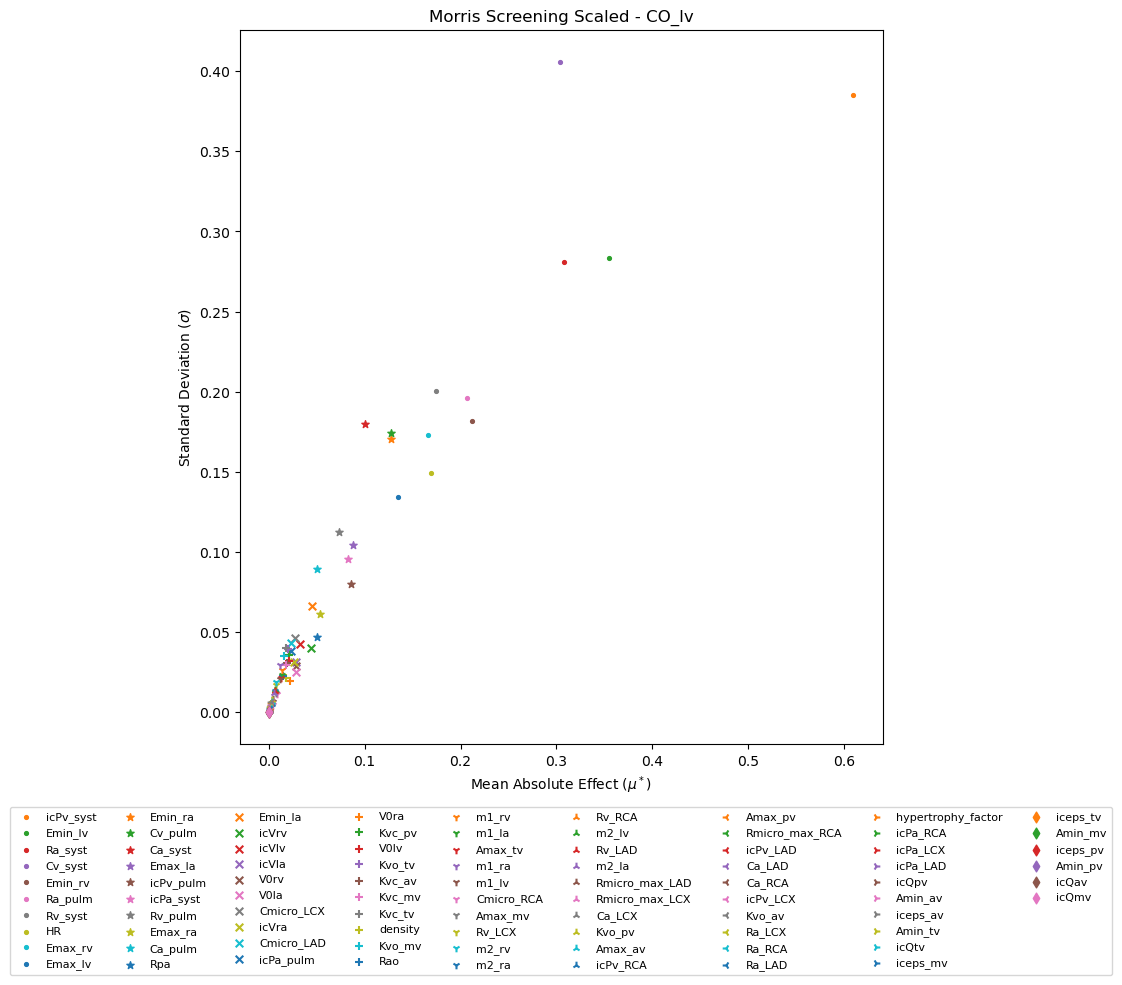


--- Morris Screening Results for Output DeltaE ---
Ra_syst: mu* = 0.4887, sigma = 0.5475         | icPv_syst: mu* = 0.4786, sigma = 0.5700
icPv_syst: mu* = 0.4786, sigma = 0.5700       | Ra_syst: mu* = 0.4887, sigma = 0.5475
HR: mu* = 0.4249, sigma = 0.4205              | Cv_syst: mu* = 0.2640, sigma = 0.4249
Emin_lv: mu* = 0.2664, sigma = 0.4039         | HR: mu* = 0.4249, sigma = 0.4205
Cv_syst: mu* = 0.2640, sigma = 0.4249         | Emin_lv: mu* = 0.2664, sigma = 0.4039
Emax_lv: mu* = 0.2310, sigma = 0.2993         | Emin_rv: mu* = 0.2192, sigma = 0.3483
Emin_rv: mu* = 0.2192, sigma = 0.3483         | Rv_syst: mu* = 0.1610, sigma = 0.3134
Ra_pulm: mu* = 0.2099, sigma = 0.2324         | Emax_lv: mu* = 0.2310, sigma = 0.2993
Rmicro_max_LAD: mu* = 0.1702, sigma = 0.1942  | Ra_pulm: mu* = 0.2099, sigma = 0.2324
Rv_syst: mu* = 0.1610, sigma = 0.3134         | Rmicro_max_LAD: mu* = 0.1702, sigma = 0.1942
Rmicro_max_LCX: mu* = 0.1557, sigma = 0.1718  | Rmicro_max_LCX: mu* = 0.1557, sigma 

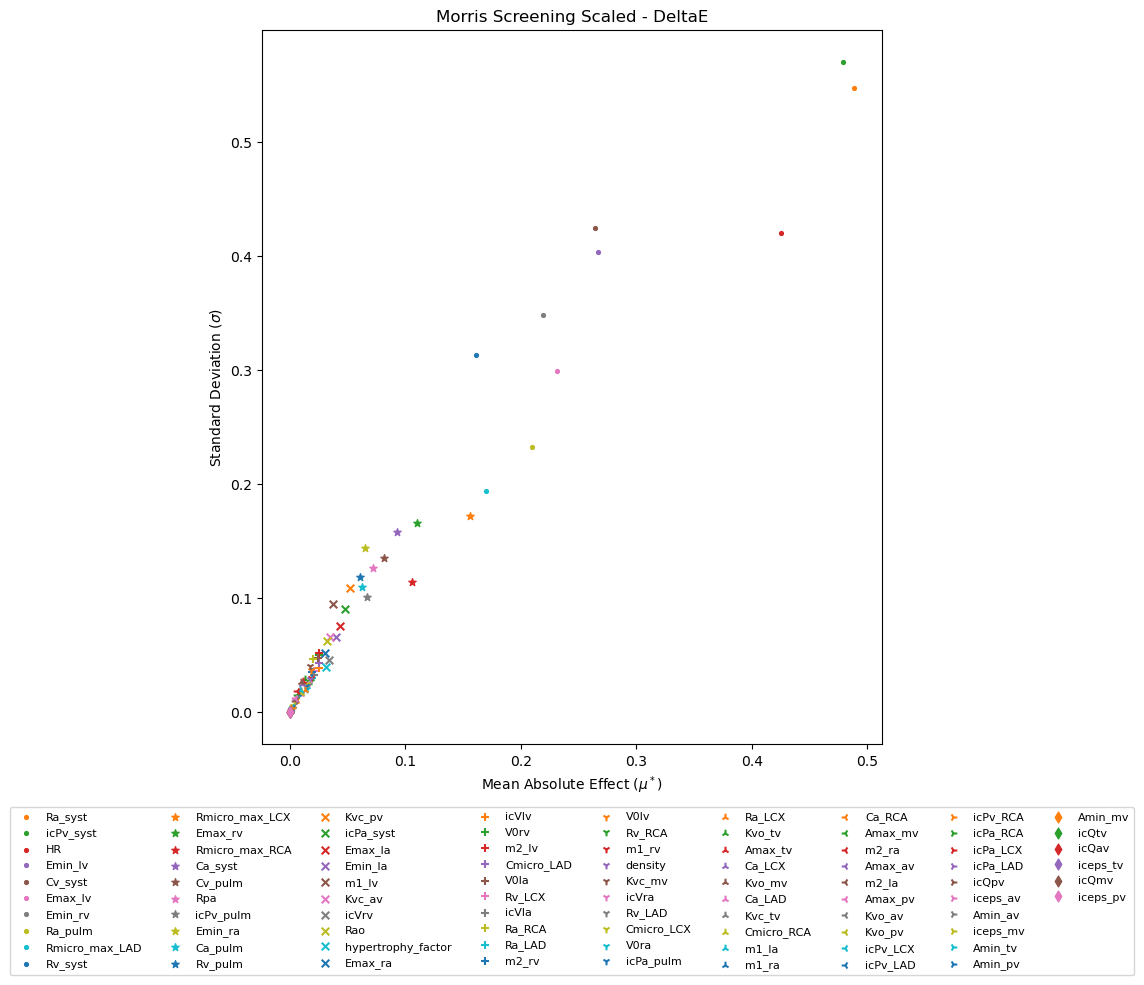


Most influential parameters across all outputs: 29 unique parameters
['Cv_syst', 'Emax_rv', 'Emax_ra', 'V0la', 'Ra_pulm', 'Rmicro_max_RCA', 'Emax_lv', 'Ra_syst', 'Ca_pulm', 'icVrv', 'Emin_lv', 'Emin_la', 'Emax_la', 'HR', 'Kvc_pv', 'Ca_syst', 'Emin_ra', 'Cv_pulm', 'icPa_syst', 'icVlv', 'Rv_syst', 'icPv_pulm', 'Rmicro_max_LAD', 'Emin_rv', 'icPv_syst', 'Rmicro_max_LCX', 'Rv_pulm', 'Rpa', 'Kvc_av']


In [ ]:


input_df_noAS = pd.read_csv("Data/morris_input_data_allparams_noAS.csv")

X = input_df_noAS.values
print("X shape:", X.shape)

output_df_noAS = pd.read_csv("Data/morris_output_data_noAS.csv")

problem = {
    "num_vars": parameters_count,
    "names": names,
    "bounds": bounds
}


N_optimal_trajectories = 80
trajectory_size = parameters_count + 1
total_trajectories = N_optimal_trajectories
output_names = output_df_noAS.keys().tolist()[2:]

most_influential_parameters = []



bad_trajectories = set([idx // trajectory_size for idx in output_df_noAS_notstability_indexes])

print(f"Dropping trajectories {len(bad_trajectories)} out of {total_trajectories}: {bad_trajectories}")

good_row_indexes = []
for t in range(total_trajectories):
    if t not in bad_trajectories:
        good_row_indexes.extend(range(t * trajectory_size, (t + 1) * trajectory_size))

X_clean = X[good_row_indexes]

for i in range(len(output_names)):
    current_output_name = output_names[i]
    if current_output_name not in ["Ein", "VO2_total", "CO_lv", "Pa_syst_mean", "DeltaE"]:
        continue
    print(f"\n--- Morris Screening Results for Output {current_output_name} ---")

    Y_clean = output_df_noAS[current_output_name].iloc[good_row_indexes].values
    
    Si_out1 = morris_analyze.analyze(problem, X_clean, Y_clean, conf_level=0.95, print_to_console=False, scaled=True)
    
    results = list(zip(problem['names'], Si_out1['mu_star'], Si_out1['sigma']))
    results.sort(key=lambda x: x[1], reverse=True)
    
    results_sort_by_variance = deepcopy(results)
    results_sort_by_variance.sort(key=lambda x: x[2], reverse=True)

    results_sort_by_name = deepcopy(results)
    results_sort_by_name.sort(key=lambda x: x[0])
    final_plot_data[f"{current_output_name}_noAS"] = results_sort_by_name

    counter = 1
    for res_mu, res_sigma in zip(results, results_sort_by_variance):
        name, mu_star, sigma = res_mu
        name2, mu_star2, sigma2 = res_sigma
        col1 = f"{name}: mu* = {mu_star:.4f}, sigma = {sigma:.4f}"
        col2 = f"{name2}: mu* = {mu_star2:.4f}, sigma = {sigma2:.4f}"
        print(f"{col1:<45} | {col2}")
        if counter < 21:
            most_influential_parameters.append(name)
            most_influential_parameters.append(name2)
            counter += 1


    plot_name = []
    plot_mu_scatter = []
    plot_sigma = []
    for name, mu_star, sigma in results:
        plot_name.append(name)
        plot_mu_scatter.append(mu_star)
        plot_sigma.append(sigma)
        
    

    plt.figure(figsize=(10, 10))
    max_mu = max(plot_mu_scatter)
    markers_styles = [".", "*", "x", "+", "1", "2", "3", "4", "d"]
    colors = cm.tab10(np.linspace(0, 1, 10))
    marker_index = 1
    for i in range(len(plot_name)):
        if i+1 > 10*marker_index:
            marker_index += 1 
        plt.scatter(plot_mu_scatter[i], plot_sigma[i], label=plot_name[i], color=colors[int((i+1)%10)], marker=markers_styles[marker_index-1], s=30)
        # plt.annotate(
        #     plot_name[i], 
        #     (plot_mu_scatter[i], plot_sigma[i]), 
        #     textcoords="offset points", 
        #     xytext=(0,0), 
        #     ha='left', 
        #     fontsize=5
        # )
    # plt.plot([0, max_mu], [0, max_mu], color='gray', linestyle='--', linewidth=1.5, zorder=0, label=r'$\mu^* = \sigma$')
    # plt.plot([0, max_mu], [0, max_mu / 2], color='lightgray', linestyle=':', linewidth=1.5, zorder=0, label=r'$\mu^* = 2\sigma$')
    plt.xlabel("Mean Absolute Effect ($\mu^*$)")
    plt.ylabel(r"Standard Deviation ($\sigma$)")
    plt.title(f"Morris Screening Scaled - {current_output_name}")
    handles, labels = plt.gca().get_legend_handles_labels()
    empty_handle = mlines.Line2D([], [], marker='None', linestyle='None')
    while len(handles) < 90:
        handles.append(empty_handle)
        labels.append('')
    plt.legend(handles=handles, labels=labels, bbox_to_anchor=(0.5, -0.08), loc="upper center", ncols=marker_index, fontsize=8, framealpha=0.8)
    #plt.legend(ncols=5, fontsize=5, framealpha=0.5)
    plt.tight_layout()
    plt.show()


    
most_influential_parameters = list(set(most_influential_parameters))
print(f"\nMost influential parameters across all outputs: {len(most_influential_parameters)} unique parameters")
print(most_influential_parameters)



# AS generate input

In [ ]:
# define names
with open("../../input_values/parameters_input.json", "r") as f:
        parameters_input = json.load(f)

print(parameters_input.keys())
names1 = list(parameters_input["chambers"].keys())
names2 = list(parameters_input["valves"].keys())
names3 = list(parameters_input["circulation"].keys())
names4 = ['Ra_LAD', 'Ra_LCX', 'Ra_RCA', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Rv_LAD', 'Rv_LCX', 'Rv_RCA', 'Ca_LAD', 'Ca_LCX', 'Ca_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor']
names5 = list(parameters_input["initial_conditions"].keys())
names = names1 + names2 + names3 + names4 + names5
print(names)
parameters_count = len(names)
print(f"Number of parameters: {parameters_count}")

# define bounds
# names1
Emax_ra_bounds = [0.17, 0.5]
Emin_ra_bounds = [0.01, 0.16]
m1_ra_bounds = [1.0, 10]
m2_ra_bounds = [5, 20]
V0ra_bounds = [-50, 30]
Emax_rv_bounds = [0.3, 1.2] 
Emin_rv_bounds = [0.01, 0.25]
m1_rv_bounds = [1.0, 10]
m2_rv_bounds = [10, 50]
V0rv_bounds = [-50, 80]
Emax_la_bounds = [0.14, 0.5]
Emin_la_bounds = [0.05, 0.13]
m1_la_bounds = [1.0, 10]
m2_la_bounds = [5, 20]
V0la_bounds = [-50, 70]
Emax_lv_bounds = [1, 4]
Emin_lv_bounds = [0.01, 0.8]
m1_lv_bounds = [1.0, 10]
m2_lv_bounds = [10, 50]
V0lv_bounds = [-50, 50]
bounds = [Emax_ra_bounds, Emin_ra_bounds, m1_ra_bounds, m2_ra_bounds, V0ra_bounds,
          Emax_rv_bounds, Emin_rv_bounds, m1_rv_bounds, m2_rv_bounds, V0rv_bounds,
          Emax_la_bounds, Emin_la_bounds, m1_la_bounds, m2_la_bounds, V0la_bounds,
          Emax_lv_bounds, Emin_lv_bounds, m1_lv_bounds, m2_lv_bounds, V0lv_bounds]

# names2
Amax_tv_bounds = [4.0, 5.0]
Amin_tv_bounds = [1e-06, 1e-05]
Kvo_tv_bounds = [0.003, 0.3]
Kvc_tv_bounds = [0.004, 0.4]
Amax_pv_bounds = [4.0, 5.0]
Amin_pv_bounds = [1e-06, 1e-05]
Kvo_pv_bounds = [0.002, 0.2]
Kvc_pv_bounds = [0.002, 0.2]
Amax_mv_bounds = [4.0, 5.0]
Amin_mv_bounds = [1e-06, 1e-05]
Kvo_mv_bounds = [0.003, 0.3]
Kvc_mv_bounds = [0.004, 0.4]
Amax_av_bounds = [0.2, 1.0]
Amin_av_bounds = [1e-06, 1e-05]
Kvo_av_bounds = [0.0012, 0.12]
Kvc_av_bounds = [0.0012, 0.12]
bounds += [
    Amax_tv_bounds, Amin_tv_bounds, Kvo_tv_bounds, Kvc_tv_bounds,
    Amax_pv_bounds, Amin_pv_bounds, Kvo_pv_bounds, Kvc_pv_bounds,
    Amax_mv_bounds, Amin_mv_bounds, Kvo_mv_bounds, Kvc_mv_bounds,
    Amax_av_bounds, Amin_av_bounds, Kvo_av_bounds, Kvc_av_bounds
]

# names3
HR_bounds = [40, 180]
density_bounds = [0.9, 1.3]
Rao_bounds = [0.01, 0.1]
Ca_syst_bounds = [0.5, 5]
Ra_syst_bounds = [0.1, 3]
Cv_syst_bounds = [10, 150]
Rv_syst_bounds = [0.01, 0.2]
Rpa_bounds = [0.001, 0.1]
Ca_pulm_bounds = [1, 10]
Ra_pulm_bounds = [0.01, 1]
Cv_pulm_bounds = [5, 50]
Rv_pulm_bounds = [0.0005, 0.05]
bounds += [
    HR_bounds, density_bounds, Rao_bounds, Ca_syst_bounds, Ra_syst_bounds, Cv_syst_bounds, Rv_syst_bounds,
    Rpa_bounds, Ca_pulm_bounds, Ra_pulm_bounds, Cv_pulm_bounds, Rv_pulm_bounds
]

# names4
Ra_LAD_bounds = [0.1, 10]
Ra_LCX_bounds = [0.1, 10]
Ra_RCA_bounds = [0.1, 10]
Rmicro_max_LAD_bounds = [43, 170]
#Rmicro_min_LAD_bounds = [25, 42]
Rmicro_max_LCX_bounds = [52, 170]
#Rmicro_min_LCX_bounds = [22, 51]
Rmicro_max_RCA_bounds = [59, 170]
#Rmicro_min_RCA_bounds = [28, 58]
Rv_LAD_bounds = [0.1, 10]
Rv_LCX_bounds = [0.1, 10]
Rv_RCA_bounds = [0.1, 10]
Ca_LAD_bounds = [0.001, 0.2]
Ca_LCX_bounds = [0.001, 0.2]
Ca_RCA_bounds = [0.001, 0.2]
Cmicro_LAD_bounds = [0.05, 2]
Cmicro_LCX_bounds = [0.05, 2]
Cmicro_RCA_bounds = [0.05, 2]
hypertrophy_factor_bounds = [1.0, 3.0]
bounds += [
    Ra_LAD_bounds, Ra_LCX_bounds, Ra_RCA_bounds,
    Rmicro_max_LAD_bounds, Rmicro_max_LCX_bounds, Rmicro_max_RCA_bounds,
    Rv_LAD_bounds, Rv_LCX_bounds, Rv_RCA_bounds, Ca_LAD_bounds, Ca_LCX_bounds, Ca_RCA_bounds,
    Cmicro_LAD_bounds, Cmicro_LCX_bounds, Cmicro_RCA_bounds, hypertrophy_factor_bounds
]

# names5
icVra_bounds = [10, 100]
icVrv_bounds = [85, 250]
icVla_bounds = [10, 100]
icVlv_bounds = [75, 250]
icQtv_bounds = [0, 1]
icQpv_bounds = [0, 1]
icQmv_bounds = [0, 1]
icQav_bounds = [0, 1]
iceps_tv_bounds = [0, 1]
iceps_pv_bounds = [0, 1]
iceps_mv_bounds = [0, 1]
iceps_av_bounds = [0, 1]
icPa_syst_bounds = [30, 140]
icPv_syst_bounds = [2, 50]
icPa_pulm_bounds = [5, 20]
icPv_pulm_bounds = [1, 14]
icPa_LAD_bounds = [40, 60]
icPv_LAD_bounds = [10, 18]
icPa_LCX_bounds = [40, 60]
icPv_LCX_bounds = [10, 18]
icPa_RCA_bounds = [40, 60]
icPv_RCA_bounds = [10, 18]
bounds += [
    icVra_bounds, icVrv_bounds, icVla_bounds, icVlv_bounds,
    icQtv_bounds, icQpv_bounds, icQmv_bounds, icQav_bounds,
    iceps_tv_bounds, iceps_pv_bounds, iceps_mv_bounds, iceps_av_bounds,
    icPa_syst_bounds, icPv_syst_bounds, icPa_pulm_bounds, icPv_pulm_bounds,
    icPa_LAD_bounds, icPv_LAD_bounds, icPa_LCX_bounds, icPv_LCX_bounds,
    icPa_RCA_bounds, icPv_RCA_bounds
]

print(bounds)
print(f"Bounds len: {len(bounds)}, expected len: {parameters_count}")



dict_keys(['chambers', 'valves', 'circulation', 'CBF_model', 'initial_conditions'])
['Emax_ra', 'Emin_ra', 'm1_ra', 'm2_ra', 'V0ra', 'Emax_rv', 'Emin_rv', 'm1_rv', 'm2_rv', 'V0rv', 'Emax_la', 'Emin_la', 'm1_la', 'm2_la', 'V0la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'm2_lv', 'V0lv', 'Amax_tv', 'Amin_tv', 'Kvo_tv', 'Kvc_tv', 'Amax_pv', 'Amin_pv', 'Kvo_pv', 'Kvc_pv', 'Amax_mv', 'Amin_mv', 'Kvo_mv', 'Kvc_mv', 'Amax_av', 'Amin_av', 'Kvo_av', 'Kvc_av', 'HR', 'density', 'Rao', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rpa', 'Ca_pulm', 'Ra_pulm', 'Cv_pulm', 'Rv_pulm', 'Ra_LAD', 'Ra_LCX', 'Ra_RCA', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Rv_LAD', 'Rv_LCX', 'Rv_RCA', 'Ca_LAD', 'Ca_LCX', 'Ca_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor', 'icVra', 'icVrv', 'icVla', 'icVlv', 'icQtv', 'icQpv', 'icQmv', 'icQav', 'iceps_tv', 'iceps_pv', 'iceps_mv', 'iceps_av', 'icPa_syst', 'icPv_syst', 'icPa_pulm', 'icPv_pulm', 'icPa_LAD', 'icPv_LAD', 'icPa_LCX', 'icPv_LCX', 'icPa_RC

In [ ]:
# Generate Dataset

problem = {
    "num_vars": parameters_count,
    "names": names,
    "bounds": bounds
}

N_trajectories = 1000
N_optimal_trajectories = 80
X = morris_sample.sample(problem, N=N_trajectories, num_levels=4, optimal_trajectories=N_optimal_trajectories, local_optimization=True)
print(f"Generated {X.shape[0]} parameter sets for Morris screening.")
print(X)

input_data = {}
for i in range(len(names)):
    input_data[names[i]] = X[:,i]

df = pd.DataFrame(input_data)
df.to_csv("Data/morris_input_data_allparams_AS.csv", index=False)



# AS Analyse results

In [7]:
# morris analysis for AS

output_df_AS = pd.read_csv("Data/morris_output_data_AS.csv")


output_df_AS_notstability = output_df_AS[output_df_AS["stability_reached"] == 0]
output_df_AS_stable = output_df_AS[output_df_AS["stability_reached"] == 1]
output_df_AS_notstability_indexes = output_df_AS_notstability.index.tolist()
print(f"Number of samples with stability issues: {len(output_df_AS_notstability)} out of {len(output_df_AS)}")
print(output_df_AS_notstability_indexes)

input_df_AS = pd.read_csv("Data/morris_input_data_allparams_AS.csv")
input_df_AS_notstability = input_df_AS.iloc[output_df_AS_notstability_indexes]
#input_df_AS_notstability.to_csv("Data/morris_input_data_AS_notstability.csv", index=False)

output_df_AS_stable.describe()




Number of samples with stability issues: 740 out of 6960
[435, 436, 437, 438, 439, 440, 441, 443, 444, 445, 540, 541, 542, 543, 544, 545, 546, 547, 548, 549, 550, 551, 552, 553, 554, 555, 556, 557, 558, 559, 560, 561, 562, 563, 564, 565, 566, 567, 568, 569, 570, 571, 572, 573, 574, 674, 675, 676, 677, 678, 679, 680, 681, 682, 683, 766, 767, 773, 774, 775, 776, 777, 778, 779, 893, 894, 895, 896, 897, 898, 899, 900, 901, 902, 903, 904, 910, 911, 912, 913, 914, 915, 916, 917, 918, 919, 920, 921, 922, 923, 924, 925, 926, 927, 957, 958, 959, 960, 961, 962, 963, 964, 965, 966, 968, 969, 970, 971, 972, 973, 974, 975, 976, 977, 978, 979, 980, 981, 982, 983, 984, 985, 986, 987, 988, 989, 990, 991, 992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1016, 1017, 1018, 1019, 1020, 1021, 1022, 1024, 1025, 1026, 1027, 1028, 1131, 1132, 1133, 1134, 1135, 1136, 1137, 1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146

,stability_reached,stability_reached_cycle,Pao_max,Pao_min,Pao_mean,Ppt_max,Ppt_min,Ppt_mean,Pa_syst_max,Pa_syst_min,...,CO_lv,RVET,LVET,Ees_rv,Ees_lv,Ea_rv,Ea_lv,VAC_rv,VAC_lv,DeltaE
count,6220.0,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,...,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000,6220.000000
mean,1.0,112.189871,102.217787,79.303546,87.784126,84.238728,39.039659,53.439125,92.599872,78.868142,...,3512.946527,0.296759,0.427450,0.574992,1.565799,1.867465,3.156171,4.989264,4.019500,-4.307996
std,0.0,78.490276,110.987016,93.014743,99.159570,73.920254,39.400322,47.130341,103.189740,93.129740,...,3167.187974,0.348333,0.452954,0.371063,1.109634,1.445305,2.385550,5.924153,6.810634,23.749139
min,1.0,11.000000,4.185786,2.745753,3.348175,1.668950,-19.974092,1.274312,4.094160,2.745285,...,48.108887,0.038853,0.035018,0.014693,0.023427,0.025152,0.212936,0.030681,0.054858,-650.184121
25%,1.0,57.000000,34.271033,23.598681,28.330373,34.314384,13.122923,21.391695,30.240926,23.087276,...,1120.137580,0.090545,0.126626,0.279574,0.720141,0.830154,1.307436,1.479853,0.876296,-3.271528
50%,1.0,88.000000,62.082606,42.484157,50.020140,62.804957,29.387374,39.425023,53.963590,41.540784,...,2592.078807,0.155553,0.262516,0.486662,1.256926,1.578466,2.339133,3.200539,1.928923,-0.277082
75%,1.0,140.000000,123.486648,96.062339,105.242667,114.259077,53.213426,70.877098,113.220727,95.799943,...,4922.129735,0.333333,0.450000,0.824023,2.240100,2.569342,4.559982,6.201414,4.598413,1.701183
max,1.0,762.000000,919.309702,816.222598,856.276815,661.608751,377.673159,409.493011,902.573426,818.333630,...,19240.787026,1.500000,1.500000,3.403619,10.181500,11.926404,12.889086,62.587518,72.442198,32.364821


X shape: (6960, 86)
Dropping trajectories 36 out of 80: {5, 6, 7, 8, 10, 11, 13, 14, 15, 16, 21, 22, 25, 27, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 54, 58, 62, 63, 66, 68, 69, 72, 75, 77, 78, 79}

--- Morris Screening Results for Output Pa_syst_mean ---
icPv_syst: mu* = 0.5835, sigma = 0.4186       | icPv_syst: mu* = 0.5835, sigma = 0.4186
Ra_syst: mu* = 0.5026, sigma = 0.4083         | Ra_syst: mu* = 0.5026, sigma = 0.4083
Emin_lv: mu* = 0.3124, sigma = 0.3044         | Cv_syst: mu* = 0.2976, sigma = 0.4011
Cv_syst: mu* = 0.2976, sigma = 0.4011         | Emin_lv: mu* = 0.3124, sigma = 0.3044
Cv_pulm: mu* = 0.1474, sigma = 0.1822         | Emin_rv: mu* = 0.1230, sigma = 0.1855
Ra_pulm: mu* = 0.1233, sigma = 0.1272         | Cv_pulm: mu* = 0.1474, sigma = 0.1822
Emin_rv: mu* = 0.1230, sigma = 0.1855         | Amax_av: mu* = 0.1097, sigma = 0.1710
Emax_lv: mu* = 0.1176, sigma = 0.1290         | Emax_lv: mu* = 0.1176, sigma = 0.1290
Amax_av: mu* = 0.1097, sigma = 0.1710         | HR: mu*

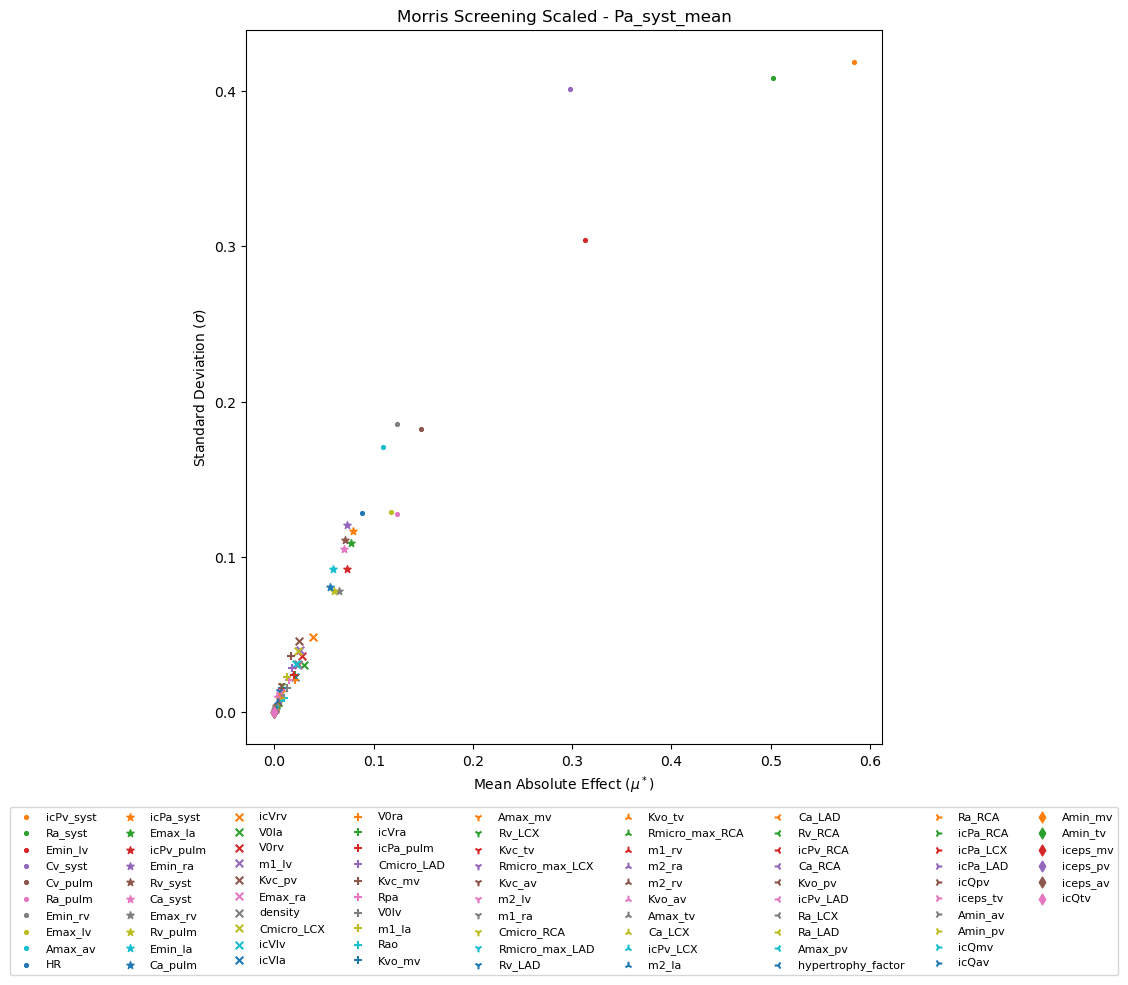


--- Morris Screening Results for Output VO2_total ---
icPv_syst: mu* = 0.5617, sigma = 0.4552       | Cv_syst: mu* = 0.4211, sigma = 0.5070
Cv_syst: mu* = 0.4211, sigma = 0.5070         | icPv_syst: mu* = 0.5617, sigma = 0.4552
Emin_lv: mu* = 0.3130, sigma = 0.4178         | Emin_lv: mu* = 0.3130, sigma = 0.4178
Emin_rv: mu* = 0.2537, sigma = 0.2686         | Emin_rv: mu* = 0.2537, sigma = 0.2686
HR: mu* = 0.1564, sigma = 0.2534              | HR: mu* = 0.1564, sigma = 0.2534
Cv_pulm: mu* = 0.1549, sigma = 0.1852         | Ra_pulm: mu* = 0.1305, sigma = 0.2317
Ra_pulm: mu* = 0.1305, sigma = 0.2317         | Cv_pulm: mu* = 0.1549, sigma = 0.1852
Emax_rv: mu* = 0.0999, sigma = 0.1732         | Emax_rv: mu* = 0.0999, sigma = 0.1732
Emin_ra: mu* = 0.0969, sigma = 0.1728         | Emin_ra: mu* = 0.0969, sigma = 0.1728
Emax_lv: mu* = 0.0840, sigma = 0.1239         | Ra_syst: mu* = 0.0748, sigma = 0.1540
Amax_av: mu* = 0.0823, sigma = 0.1404         | Emax_la: mu* = 0.0750, sigma = 0.1447
Ca

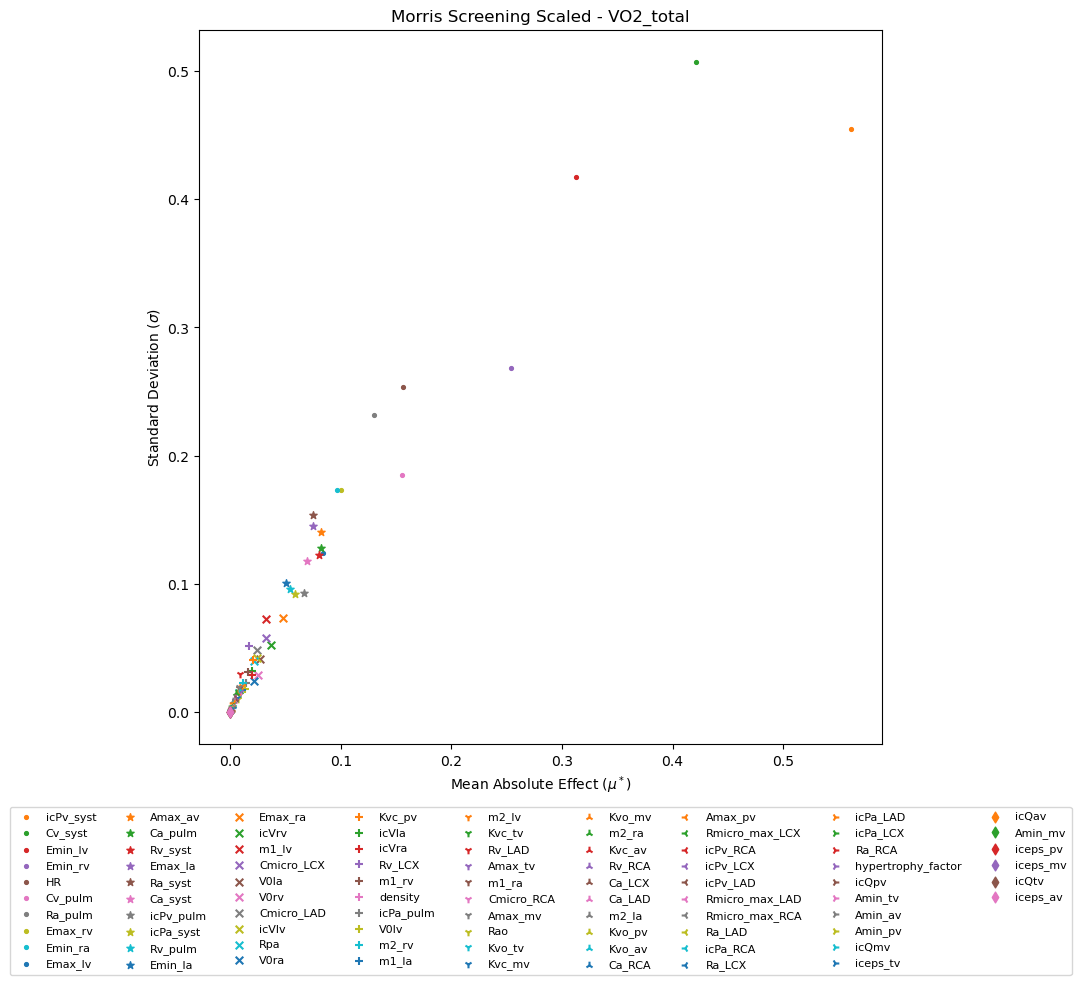


--- Morris Screening Results for Output Ein ---
Ra_syst: mu* = 0.5269, sigma = 0.4468         | Ra_syst: mu* = 0.5269, sigma = 0.4468
icPv_syst: mu* = 0.5106, sigma = 0.4089       | icPv_syst: mu* = 0.5106, sigma = 0.4089
HR: mu* = 0.4815, sigma = 0.3572              | Cv_syst: mu* = 0.3004, sigma = 0.4084
Emin_lv: mu* = 0.3229, sigma = 0.3072         | HR: mu* = 0.4815, sigma = 0.3572
Cv_syst: mu* = 0.3004, sigma = 0.4084         | Emin_lv: mu* = 0.3229, sigma = 0.3072
Emin_rv: mu* = 0.1650, sigma = 0.1557         | Cv_pulm: mu* = 0.1419, sigma = 0.2241
Emax_lv: mu* = 0.1584, sigma = 0.1838         | Emin_ra: mu* = 0.1040, sigma = 0.2058
Rmicro_max_LAD: mu* = 0.1564, sigma = 0.1605  | Emax_lv: mu* = 0.1584, sigma = 0.1838
Cv_pulm: mu* = 0.1419, sigma = 0.2241         | Amax_av: mu* = 0.0829, sigma = 0.1641
Ra_pulm: mu* = 0.1387, sigma = 0.1292         | Rmicro_max_LAD: mu* = 0.1564, sigma = 0.1605
Rmicro_max_LCX: mu* = 0.1382, sigma = 0.1471  | Emin_rv: mu* = 0.1650, sigma = 0.1557
R

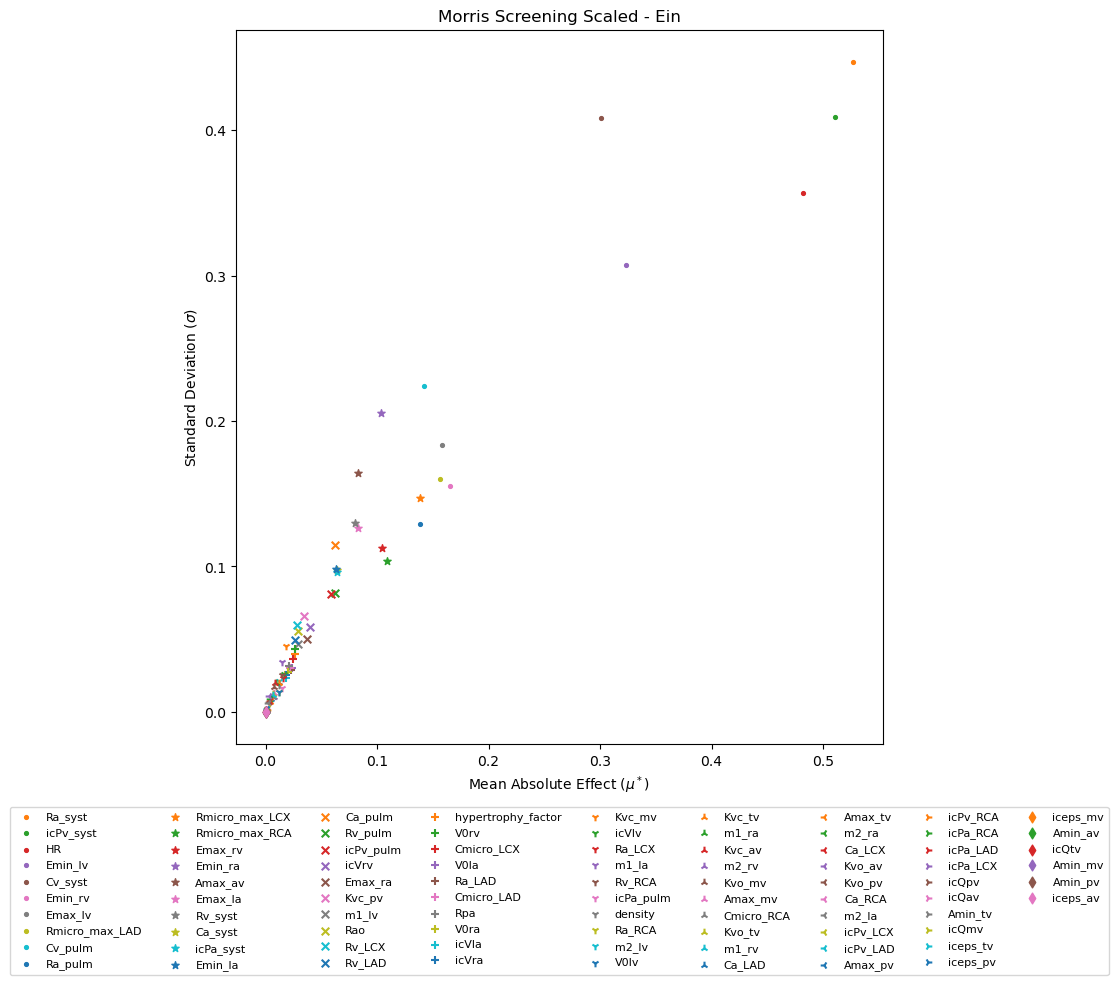


--- Morris Screening Results for Output CO_lv ---
icPv_syst: mu* = 0.5581, sigma = 0.3934       | icPv_syst: mu* = 0.5581, sigma = 0.3934
Emin_lv: mu* = 0.3627, sigma = 0.3256         | Cv_syst: mu* = 0.3328, sigma = 0.3669
Cv_syst: mu* = 0.3328, sigma = 0.3669         | Emin_lv: mu* = 0.3627, sigma = 0.3256
Ra_syst: mu* = 0.2521, sigma = 0.2537         | Ra_syst: mu* = 0.2521, sigma = 0.2537
Emin_rv: mu* = 0.2452, sigma = 0.2351         | Emin_rv: mu* = 0.2452, sigma = 0.2351
Ra_pulm: mu* = 0.1681, sigma = 0.1405         | Amax_av: mu* = 0.1392, sigma = 0.1749
Amax_av: mu* = 0.1392, sigma = 0.1749         | HR: mu* = 0.1093, sigma = 0.1598
Cv_pulm: mu* = 0.1376, sigma = 0.1344         | Ra_pulm: mu* = 0.1681, sigma = 0.1405
Emax_rv: mu* = 0.1246, sigma = 0.1204         | Cv_pulm: mu* = 0.1376, sigma = 0.1344
Emax_lv: mu* = 0.1229, sigma = 0.1274         | Emin_ra: mu* = 0.1152, sigma = 0.1298
Emin_ra: mu* = 0.1152, sigma = 0.1298         | Rv_pulm: mu* = 0.0790, sigma = 0.1274
HR: mu

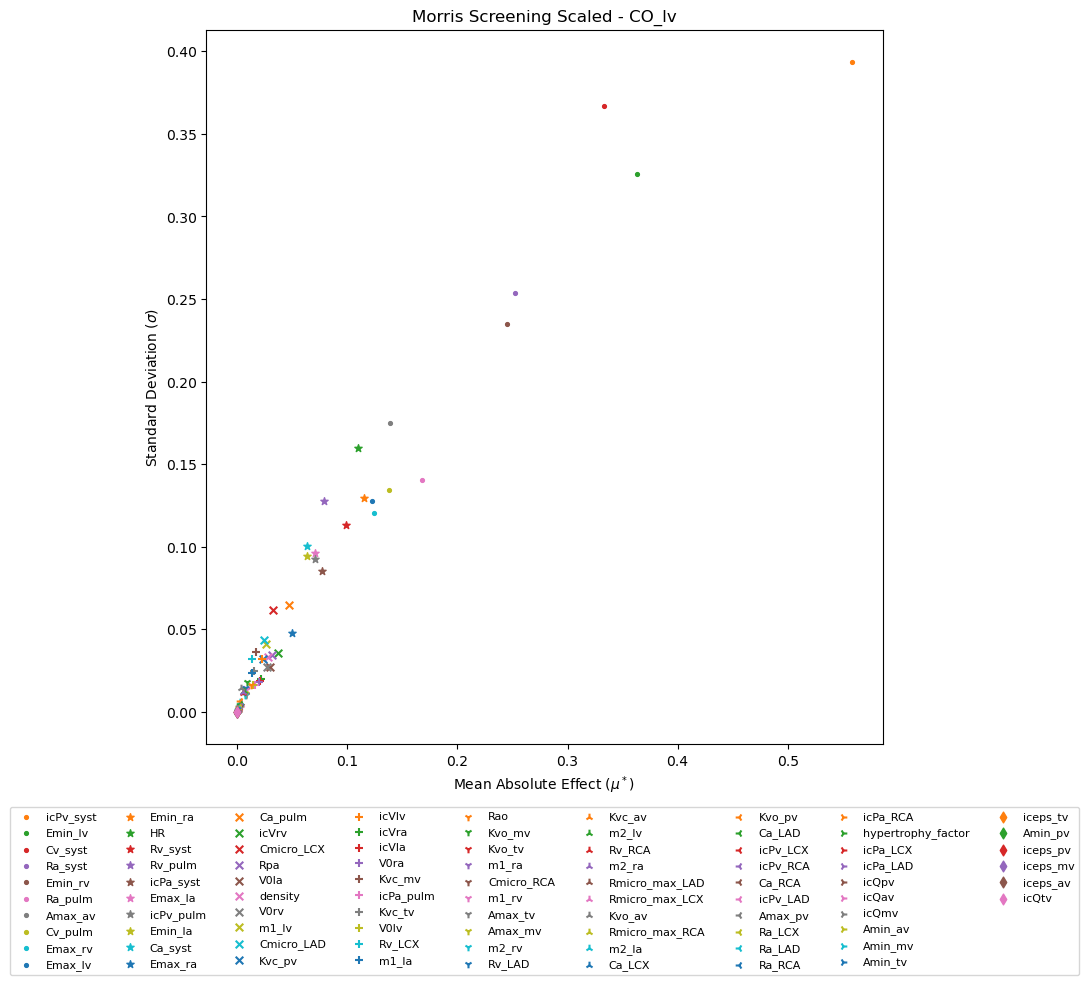


--- Morris Screening Results for Output DeltaE ---
Ra_syst: mu* = 0.4126, sigma = 0.3933         | Emin_lv: mu* = 0.3095, sigma = 0.5761
icPv_syst: mu* = 0.3751, sigma = 0.4976       | icPv_syst: mu* = 0.3751, sigma = 0.4976
HR: mu* = 0.3436, sigma = 0.4169              | Cv_syst: mu* = 0.3341, sigma = 0.4503
Cv_syst: mu* = 0.3341, sigma = 0.4503         | HR: mu* = 0.3436, sigma = 0.4169
Emin_lv: mu* = 0.3095, sigma = 0.5761         | Ra_syst: mu* = 0.4126, sigma = 0.3933
Emin_rv: mu* = 0.1980, sigma = 0.2992         | Emin_rv: mu* = 0.1980, sigma = 0.2992
Ra_pulm: mu* = 0.1485, sigma = 0.2483         | Ra_pulm: mu* = 0.1485, sigma = 0.2483
Rmicro_max_LAD: mu* = 0.1381, sigma = 0.2470  | Rmicro_max_LAD: mu* = 0.1381, sigma = 0.2470
Emax_lv: mu* = 0.1211, sigma = 0.1711         | Emax_rv: mu* = 0.1100, sigma = 0.1965
Rmicro_max_LCX: mu* = 0.1207, sigma = 0.1215  | Amax_av: mu* = 0.1076, sigma = 0.1807
Cv_pulm: mu* = 0.1106, sigma = 0.1750         | Cv_pulm: mu* = 0.1106, sigma = 0.175

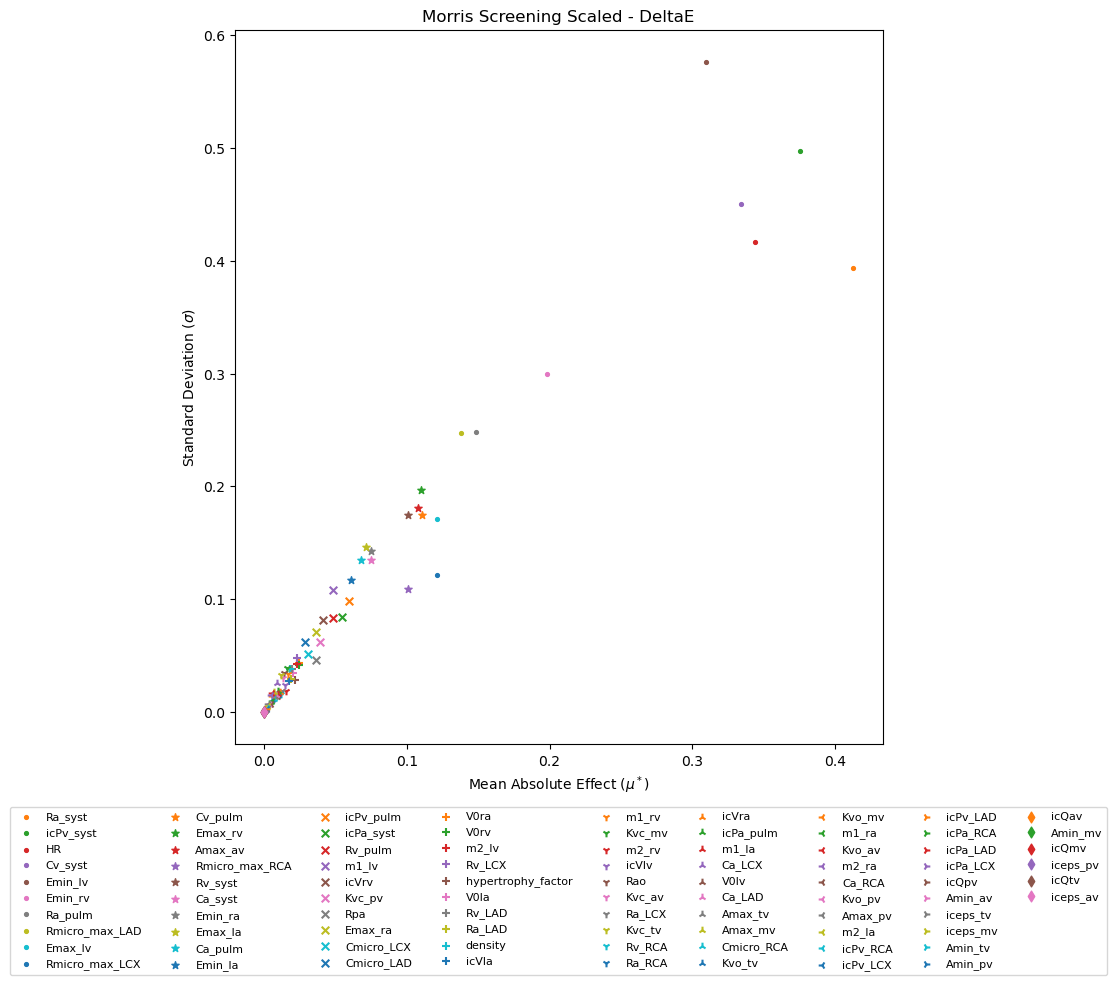


Most influential parameters across all outputs: 24 unique parameters
['Cv_syst', 'Emax_rv', 'Emax_ra', 'Ra_pulm', 'Rmicro_max_RCA', 'Emax_lv', 'Ra_syst', 'Ca_pulm', 'Emin_lv', 'Emin_la', 'Emax_la', 'HR', 'Ca_syst', 'Emin_ra', 'Cv_pulm', 'icPa_syst', 'icPv_pulm', 'Rv_syst', 'Emin_rv', 'icPv_syst', 'Rmicro_max_LCX', 'Rv_pulm', 'Amax_av', 'Rmicro_max_LAD']


In [ ]:
input_df_AS = pd.read_csv("Data/morris_input_data_allparams_AS.csv")

X = input_df_AS.values
print("X shape:", X.shape)

output_df_AS = pd.read_csv("Data/morris_output_data_AS.csv")

problem = {
    "num_vars": parameters_count,
    "names": names,
    "bounds": bounds
}


N_optimal_trajectories = 80
trajectory_size = parameters_count + 1
total_trajectories = N_optimal_trajectories
output_names = output_df_AS.keys().tolist()[2:]

most_influential_parameters = []



bad_trajectories = set([idx // trajectory_size for idx in output_df_AS_notstability_indexes])

print(f"Dropping trajectories {len(bad_trajectories)} out of {total_trajectories}: {bad_trajectories}")

good_row_indexes = []
for t in range(total_trajectories):
    if t not in bad_trajectories:
        good_row_indexes.extend(range(t * trajectory_size, (t + 1) * trajectory_size))

X_clean = X[good_row_indexes]

for i in range(len(output_names)):
    current_output_name = output_names[i]
    if current_output_name not in ["Ein", "VO2_total", "CO_lv", "Pa_syst_mean", "DeltaE"]:
        continue
    print(f"\n--- Morris Screening Results for Output {current_output_name} ---")

    Y_clean = output_df_AS[current_output_name].iloc[good_row_indexes].values
    
    Si_out1 = morris_analyze.analyze(problem, X_clean, Y_clean, conf_level=0.95, print_to_console=False, scaled=True)
    
    results = list(zip(problem['names'], Si_out1['mu_star'], Si_out1['sigma']))
    results.sort(key=lambda x: x[1], reverse=True)
    
    results_sort_by_variance = deepcopy(results)
    results_sort_by_variance.sort(key=lambda x: x[2], reverse=True)

    results_sort_by_name = deepcopy(results)
    results_sort_by_name.sort(key=lambda x: x[0])
    final_plot_data[f"{current_output_name}_AS"] = results_sort_by_name

    counter = 1
    for res_mu, res_sigma in zip(results, results_sort_by_variance):
        name, mu_star, sigma = res_mu
        name2, mu_star2, sigma2 = res_sigma
        col1 = f"{name}: mu* = {mu_star:.4f}, sigma = {sigma:.4f}"
        col2 = f"{name2}: mu* = {mu_star2:.4f}, sigma = {sigma2:.4f}"
        print(f"{col1:<45} | {col2}")
        if counter < 21:
            most_influential_parameters.append(name)
            most_influential_parameters.append(name2)
            counter += 1


    plot_name = []
    plot_mu_scatter = []
    plot_sigma = []
    for name, mu_star, sigma in results:
        plot_name.append(name)
        plot_mu_scatter.append(mu_star)
        plot_sigma.append(sigma)
        
    

    # scater plot
    plt.figure(figsize=(10, 10))
    max_mu = max(plot_mu_scatter)
    markers_styles = [".", "*", "x", "+", "1", "2", "3", "4", "d"]
    colors = cm.tab10(np.linspace(0, 1, 10))
    marker_index = 1
    for i in range(len(plot_name)):
        if i+1 > 10*marker_index:
            marker_index += 1 
        plt.scatter(plot_mu_scatter[i], plot_sigma[i], label=plot_name[i], color=colors[int((i+1)%10)], marker=markers_styles[marker_index-1], s=30)
        # plt.annotate(
        #     plot_name[i], 
        #     (plot_mu_scatter[i], plot_sigma[i]), 
        #     textcoords="offset points", 
        #     xytext=(0,0), 
        #     ha='left', 
        #     fontsize=5
        # )
    # plt.plot([0, max_mu], [0, max_mu], color='gray', linestyle='--', linewidth=1.5, zorder=0, label=r'$\mu^* = \sigma$')
    # plt.plot([0, max_mu], [0, max_mu / 2], color='lightgray', linestyle=':', linewidth=1.5, zorder=0, label=r'$\mu^* = 2\sigma$')
    plt.xlabel("Mean Absolute Effect ($\mu^*$)")
    plt.ylabel(r"Standard Deviation ($\sigma$)")
    plt.title(f"Morris Screening Scaled - {current_output_name}")
    handles, labels = plt.gca().get_legend_handles_labels()
    empty_handle = mlines.Line2D([], [], marker='None', linestyle='None')
    while len(handles) < 90:
        handles.append(empty_handle)
        labels.append('')
    plt.legend(handles=handles, labels=labels, bbox_to_anchor=(0.5, -0.08), loc="upper center", ncols=marker_index, fontsize=8, framealpha=0.8)
    #plt.legend(ncols=5, fontsize=5, framealpha=0.5)
    plt.tight_layout()
    plt.show()


    
most_influential_parameters = list(set(most_influential_parameters))
print(f"\nMost influential parameters across all outputs: {len(most_influential_parameters)} unique parameters")
print(most_influential_parameters)



# Plot

['CO_lv_AS', 'CO_lv_noAS', 'DeltaE_AS', 'DeltaE_noAS', 'Ein_AS', 'Ein_noAS', 'Pa_syst_mean_AS', 'Pa_syst_mean_noAS', 'VO2_total_AS', 'VO2_total_noAS']


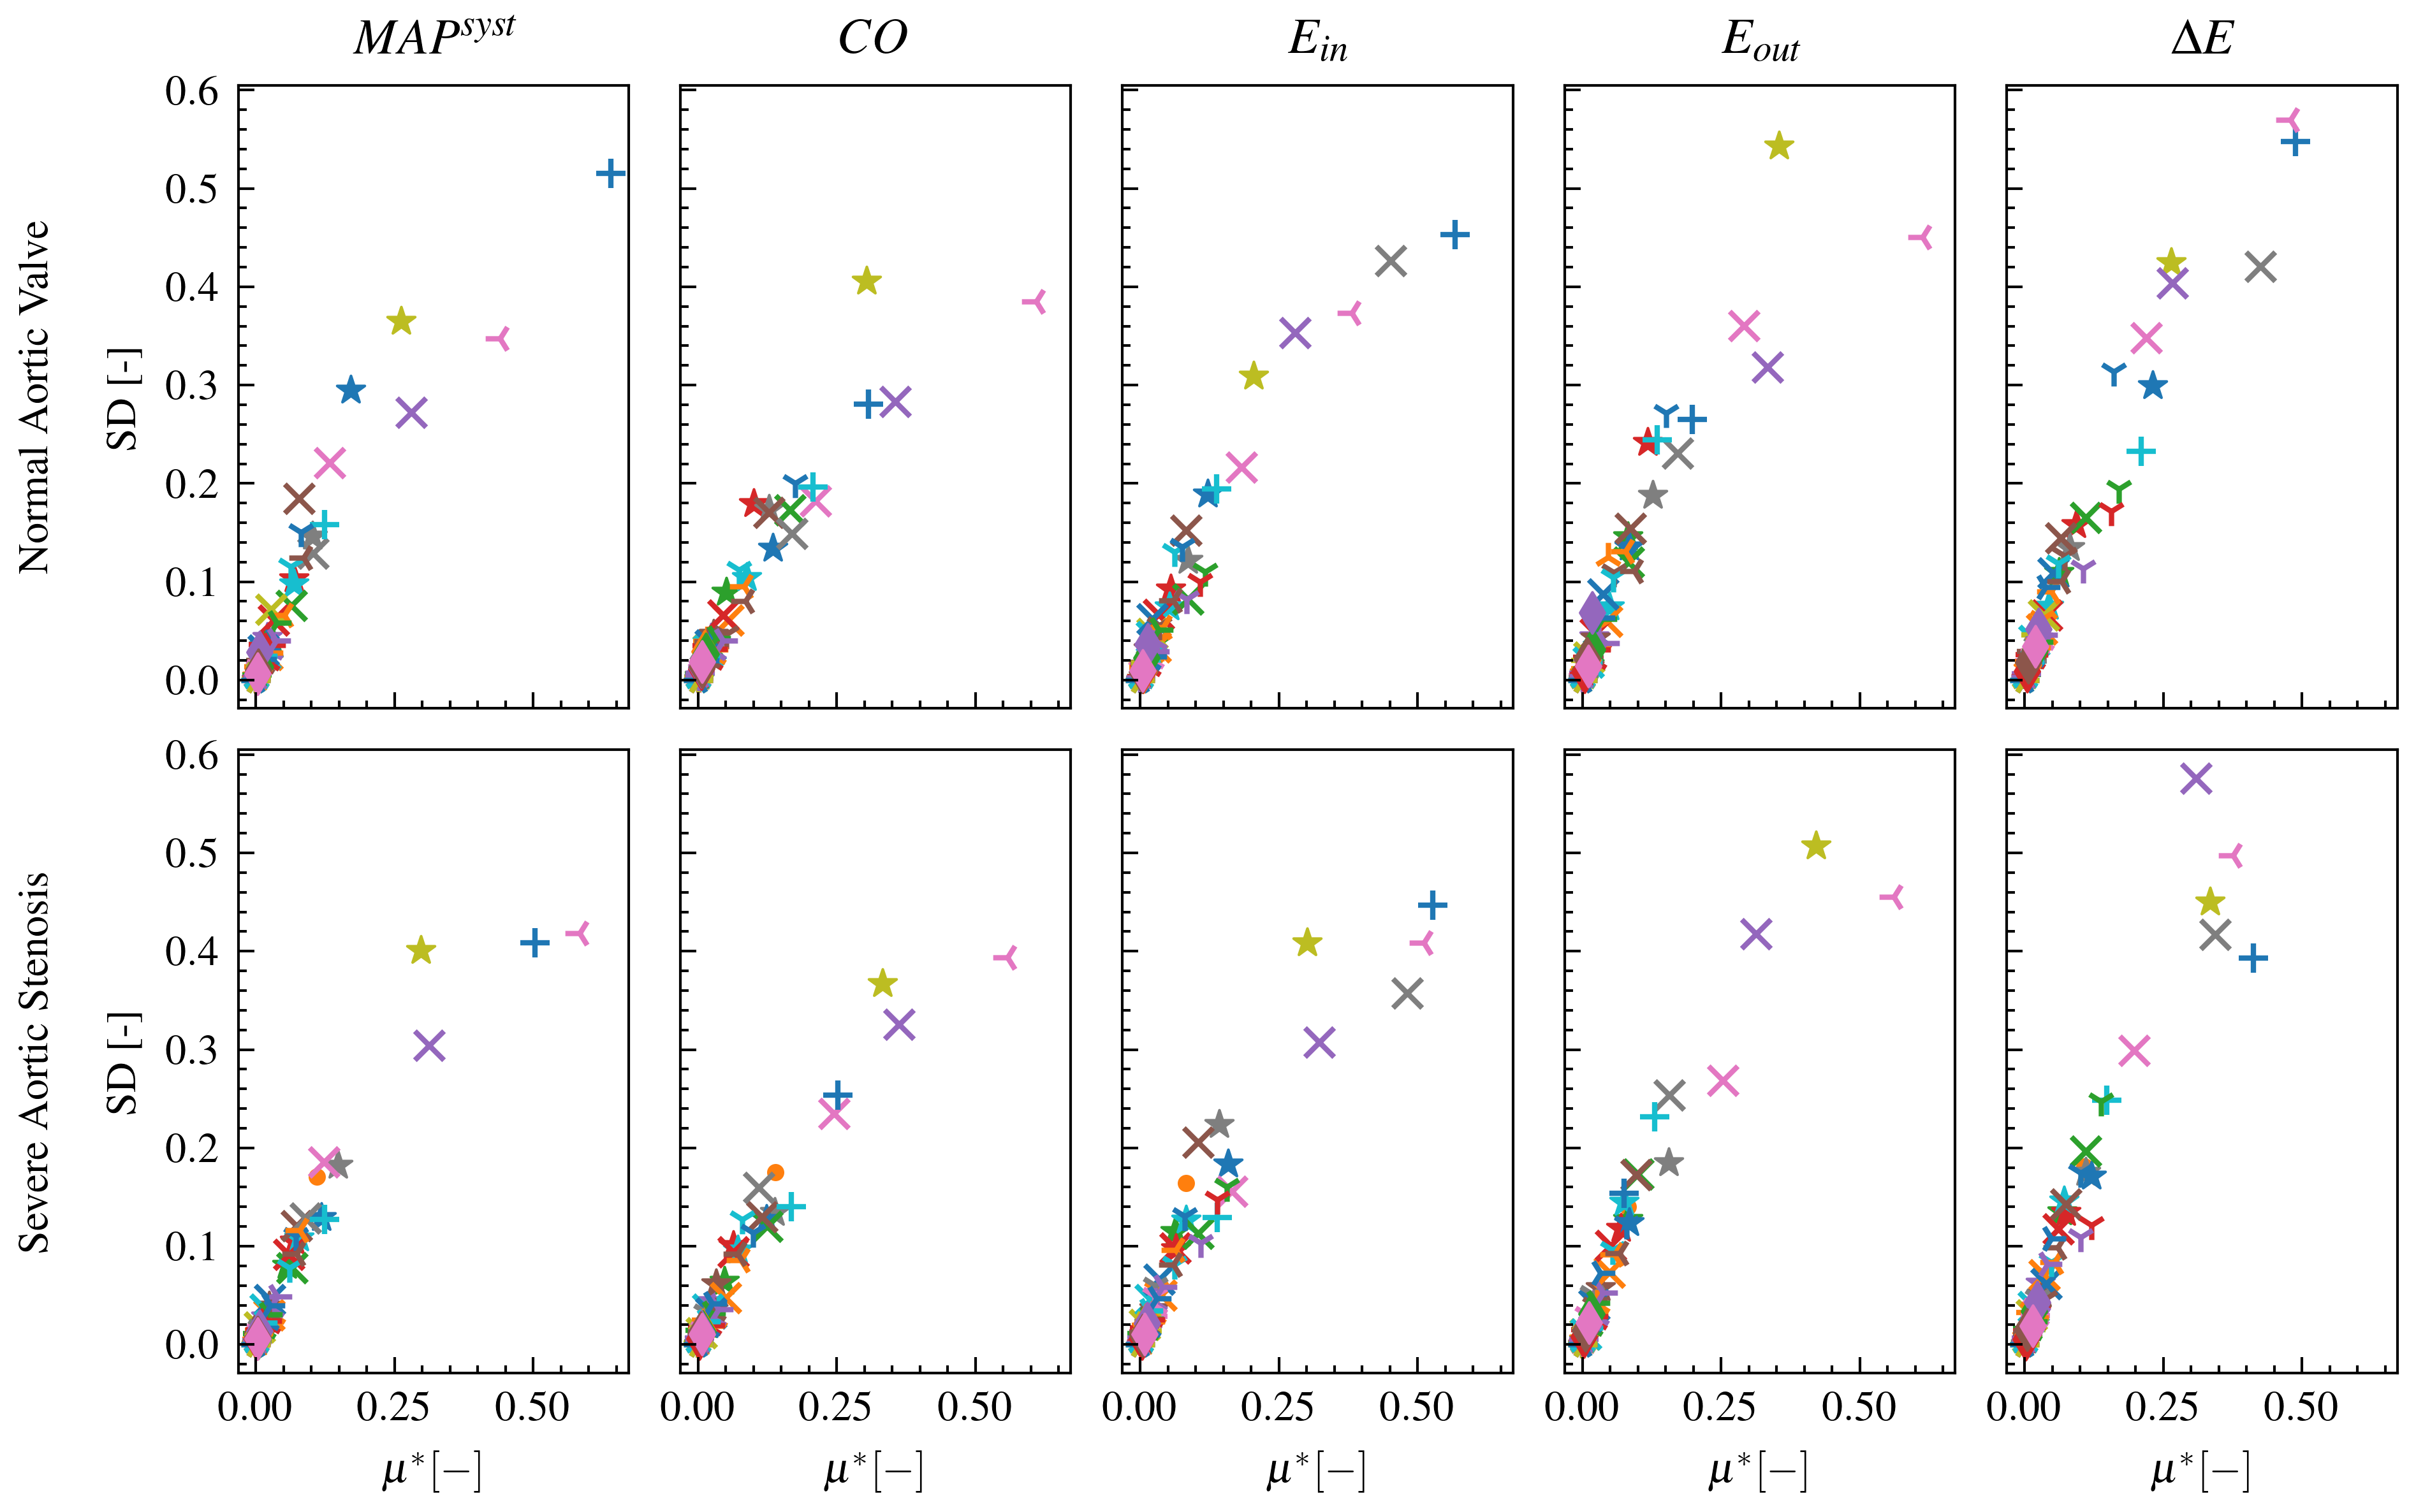

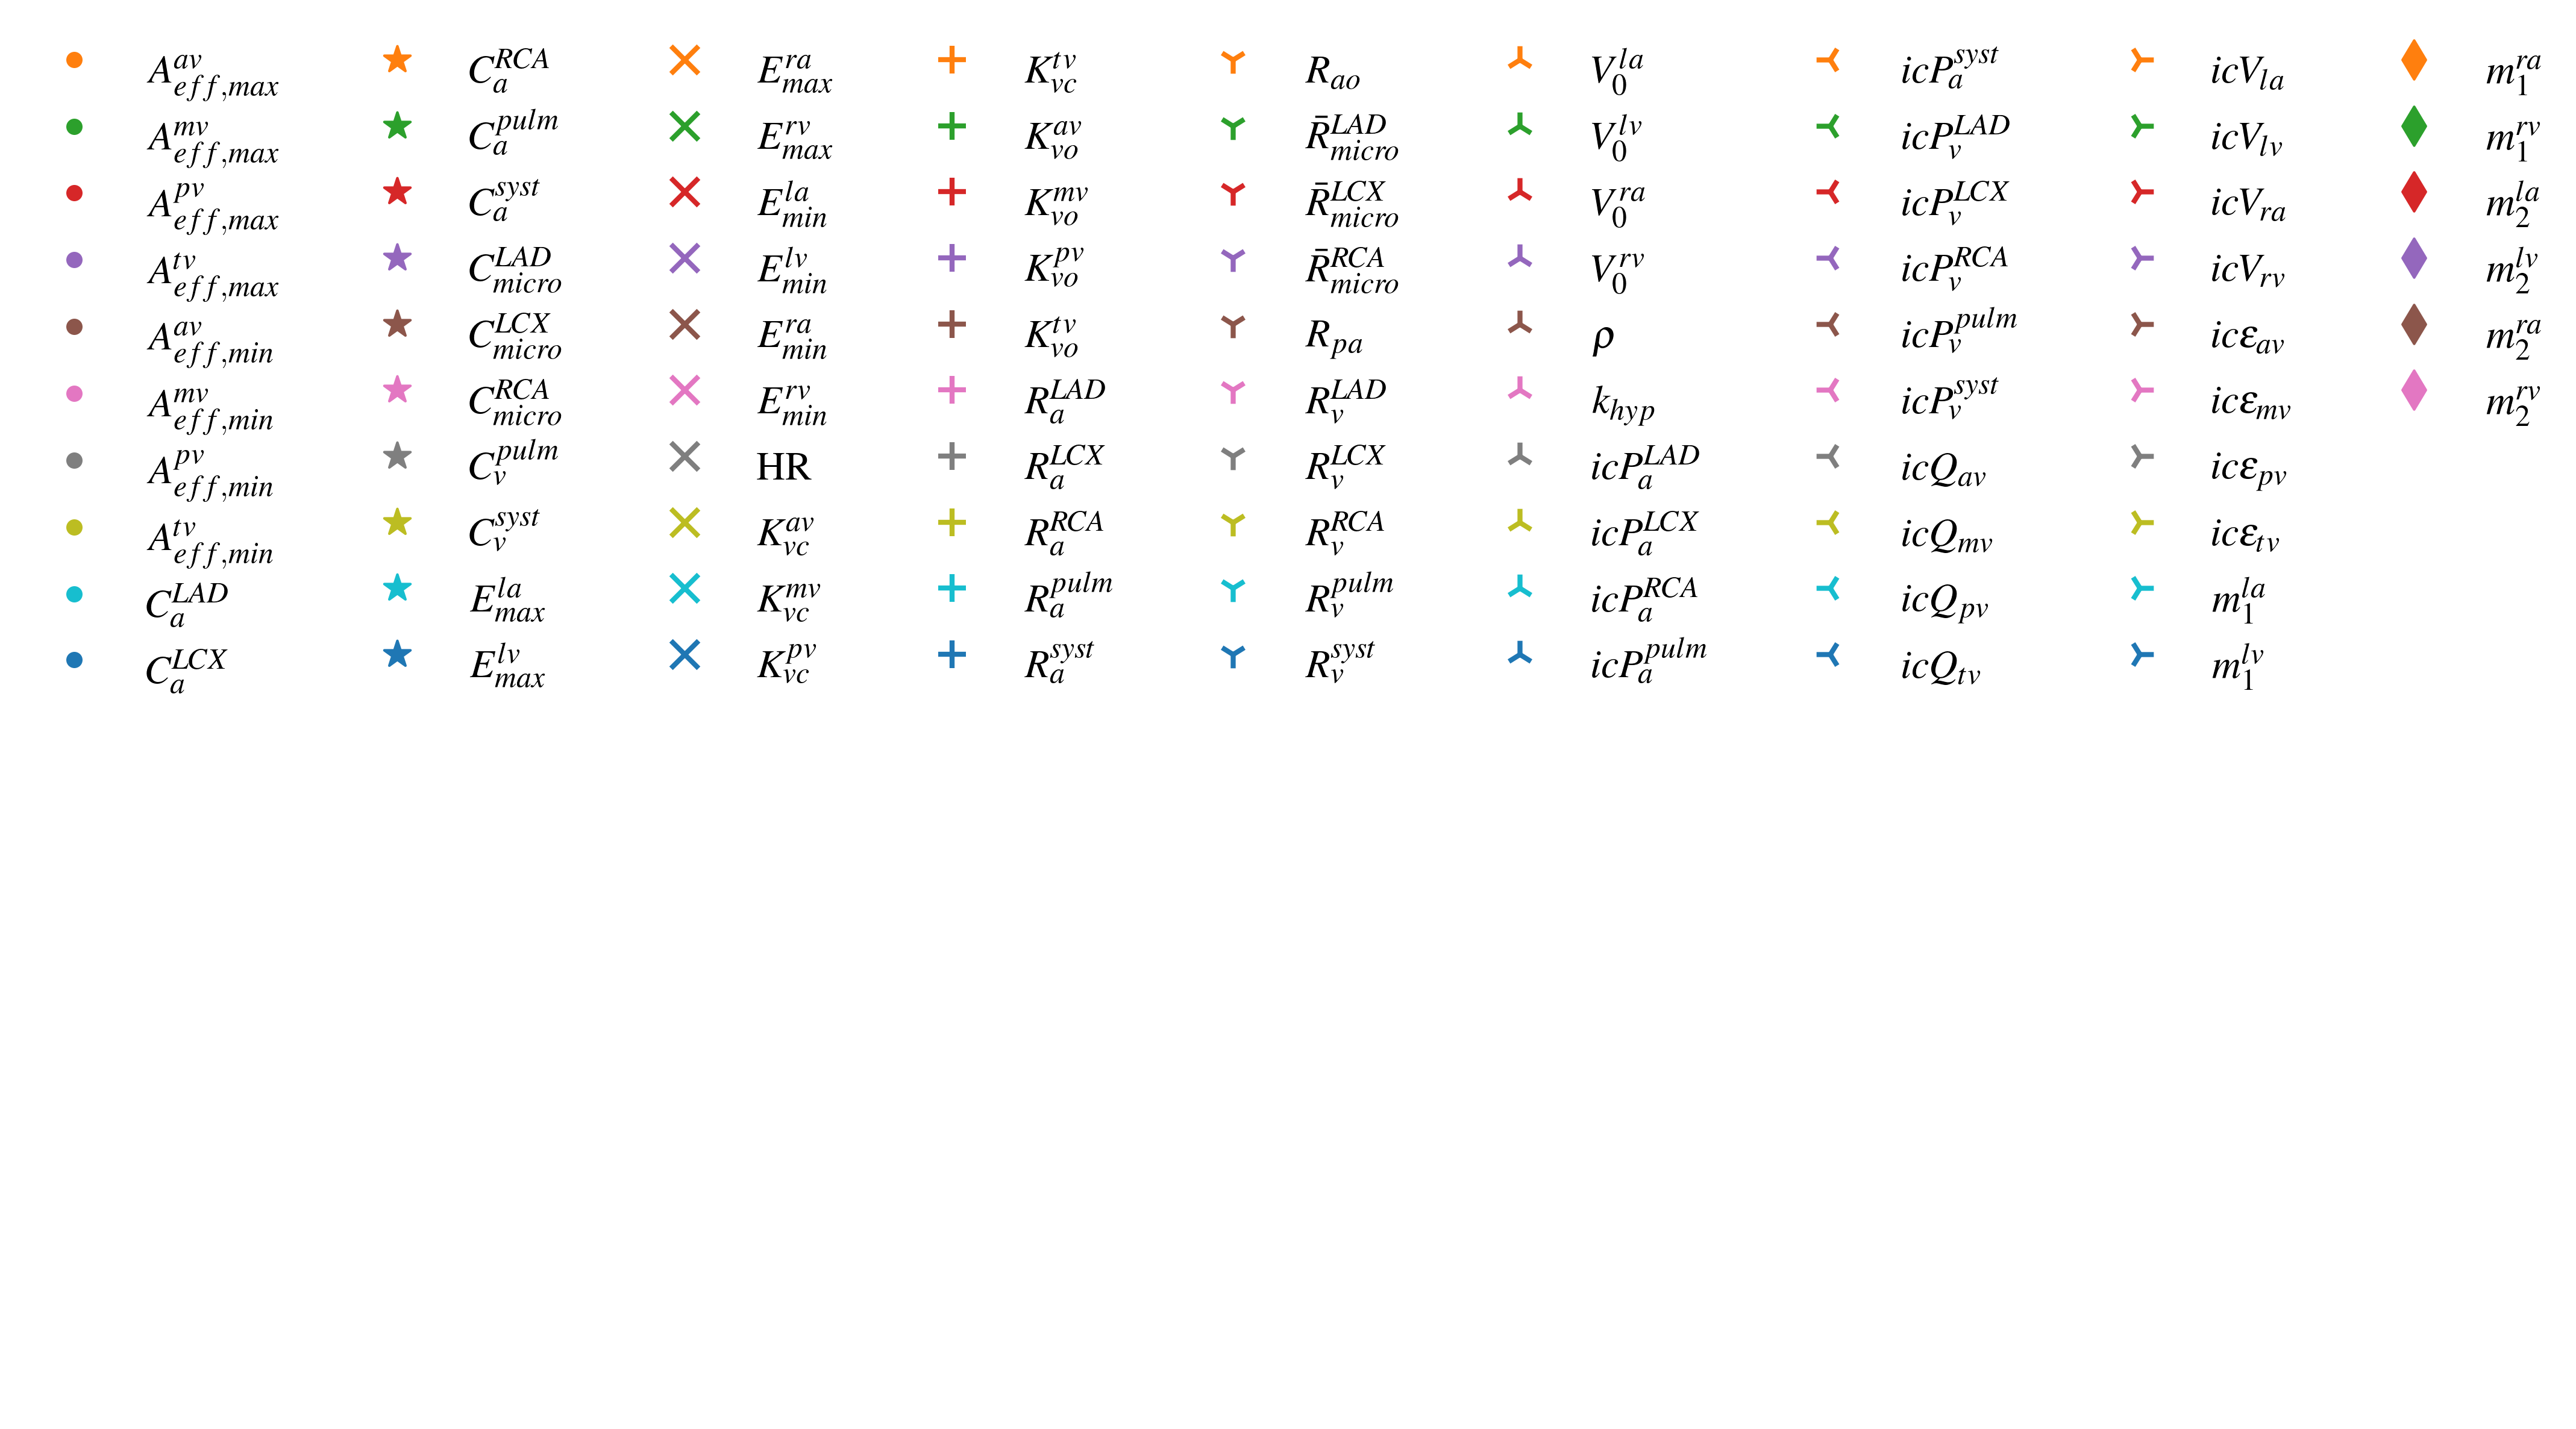

In [ ]:
# plot

import scienceplots
plt.style.use(['science','ieee'])
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams.update({
    "font.family": "serif",   
    "font.serif": ["Times"],  
    "font.size": 8})          
plt.rcParams['patch.linewidth'] = 0.5

print(sorted(final_plot_data.keys()))

centimeter = 1/2.54
plot_names = [r"$MAP^{syst}$", r"$CO$", r"$E_{in}$", r"$E_{out}$", r"$\Delta E$"]

params = ['Emax_ra', 'Emin_ra', 'm1_ra', 'm2_ra', 'V0ra', 'Emax_rv', 'Emin_rv', 'm1_rv', 'm2_rv', 'V0rv',
          'Emax_la', 'Emin_la', 'm1_la', 'm2_la', 'V0la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'm2_lv', 'V0lv',
          'Amax_tv', 'Amin_tv', 'Kvo_tv', 'Kvc_tv', 'Amax_pv', 'Amin_pv', 'Kvo_pv', 'Kvc_pv',
          'Amax_mv', 'Amin_mv', 'Kvo_mv', 'Kvc_mv', 'Amax_av', 'Amin_av', 'Kvo_av', 'Kvc_av',
          'HR', 'density', 'Rao', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst',
          'Rpa', 'Ca_pulm', 'Ra_pulm', 'Cv_pulm', 'Rv_pulm', 'Ra_LAD', 'Ra_LCX', 'Ra_RCA',
          'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Rv_LAD', 'Rv_LCX', 'Rv_RCA',
          'Ca_LAD', 'Ca_LCX', 'Ca_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor',
          'icVra', 'icVrv', 'icVla', 'icVlv', 'icQtv', 'icQpv', 'icQmv', 'icQav', 'iceps_tv', 'iceps_pv', 'iceps_mv', 'iceps_av',
          'icPa_syst', 'icPv_syst', 'icPa_pulm', 'icPv_pulm', 'icPa_LAD', 'icPv_LAD', 'icPa_LCX', 'icPv_LCX', 'icPa_RCA', 'icPv_RCA']

params_plot = [r'$E_{max}^{ra}$', r'$E_{min}^{ra}$', r'$m_{1}^{ra}$', r'$m_{2}^{ra}$', r'$V_{0}^{ra}$', r'$E_{max}^{rv}$', r'$E_{min}^{rv}$', r'$m_{1}^{rv}$', r'$m_{2}^{rv}$', r'$V_{0}^{rv}$',
          r'$E_{max}^{la}$', r'$E_{min}^{la}$', r'$m_{1}^{la}$', r'$m_{2}^{la}$', r'$V_{0}^{la}$', r'$E_{max}^{lv}$', r'$E_{min}^{lv}$', r'$m_{1}^{lv}$', r'$m_{2}^{lv}$', r'$V_{0}^{lv}$',
          r'$A_{eff,max}^{tv}$', r'$A_{eff,min}^{tv}$', r'$K_{vo}^{tv}$', r'$K_{vc}^{tv}$', r'$A_{eff,max}^{pv}$', r'$A_{eff,min}^{pv}$', r'$K_{vo}^{pv}$', r'$K_{vc}^{pv}$',
          r'$A_{eff,max}^{mv}$', r'$A_{eff,min}^{mv}$', r'$K_{vo}^{mv}$', r'$K_{vc}^{mv}$', r'$A_{eff,max}^{av}$', r'$A_{eff,min}^{av}$', r'$K_{vo}^{av}$', r'$K_{vc}^{av}$',
          r'HR', r'$\rho$', r'$R_{ao}$', r'$C_{a}^{syst}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'$R_{v}^{syst}$',
          r'$R_{pa}$', r'$C_{a}^{pulm}$', r'$R_{a}^{pulm}$', r'$C_{v}^{pulm}$', r'$R_{v}^{pulm}$', r'$R_{a}^{LAD}$', r'$R_{a}^{LCX}$', r'$R_{a}^{RCA}$',
          r'$\bar{R}_{micro}^{LAD}$', r'$\bar{R}_{micro}^{LCX}$', r'$\bar{R}_{micro}^{RCA}$', r'$R_{v}^{LAD}$', r'$R_{v}^{LCX}$', r'$R_{v}^{RCA}$',
          r'$C_{a}^{LAD}$', r'$C_{a}^{LCX}$', r'$C_{a}^{RCA}$', r'$C_{micro}^{LAD}$', r'$C_{micro}^{LCX}$', r'$C_{micro}^{RCA}$', r'$k_{hyp}$',
          r'$icV_{ra}$', r'$icV_{rv}$', r'$icV_{la}$', r'$icV_{lv}$', r'$icQ_{tv}$', r'$icQ_{pv}$', r'$icQ_{mv}$', r'$icQ_{av}$', r'$ic\varepsilon_{tv}$', r'$ic\varepsilon_{pv}$', r'$ic\varepsilon_{mv}$', r'$ic\varepsilon_{av}$',
          r'$icP_{a}^{syst}$', r'$icP_{v}^{syst}$', r'$icP_{a}^{pulm}$', r'$icP_{v}^{pulm}$', r'$icP_{a}^{LAD}$', r'$icP_{v}^{LAD}$', r'$icP_{a}^{LCX}$', r'$icP_{v}^{LCX}$', r'$icP_{a}^{RCA}$', r'$icP_{v}^{RCA}$']

fig, axs = plt.subplots(2, 5, figsize=(16*centimeter, 10*centimeter), layout='constrained', sharex=True, sharey=True) # 18,7

markers_styles = [".", "*", "x", "+", "1", "2", "3", "4", "d"]
colors = cm.tab10(np.linspace(0, 1, 10))
i = 0
j = 0
for x in final_plot_data.keys():
    if x.endswith("_noAS"):
        j = 0
    else:
        j = 1
    if x.startswith("Pa_syst_mean"):
        i = 0
    elif x.startswith("CO_lv"):
        i = 1
    elif x.startswith("Ein"):
        i = 2
    elif x.startswith("VO2_total"):
        i = 3
    elif x.startswith("DeltaE"):
        i = 4

    plot_name = []
    plot_mu = []
    plot_sigma = []
    for name, mu_star, sigma in final_plot_data[x]:
        plot_name.append(name)
        plot_mu.append(mu_star)
        plot_sigma.append(sigma)

    marker_index = 1
    for inx in range(len(plot_name)):
        if inx+1 > 10*marker_index:
            marker_index += 1 
        plot_index = params.index(plot_name[inx])
        axs[j, i].scatter(plot_mu[inx], plot_sigma[inx], label=params_plot[plot_index], color=colors[int((inx+1)%10)], marker=markers_styles[marker_index-1], s=30)

    if j == 0:
        axs[j, i].set_title(plot_names[i])
    else:
        axs[j, i].set_xlabel(r"$\mu^* [-]$")

axs[0, 0].set_ylabel("Normal Aortic Valve" + "\n" + "\n" + r"SD [-]", 
                    fontsize=8, 
                    multialignment='center')
axs[1, 0].set_ylabel("Severe Aortic Stenosis" + "\n" + "\n" + r"SD [-]", 
                    fontsize=8, 
                    multialignment='center')

handles, labels = axs[0,0].get_legend_handles_labels()
empty_handle = mlines.Line2D([], [], marker='None', linestyle='None')
while len(handles) < 90:
    handles.append(empty_handle)
    labels.append('')
#fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0.5, 0.00), loc="upper center", ncols=marker_index, fontsize=8, framealpha=1.0)

plt.savefig("Figures/morris_comparison_final.svg", bbox_inches="tight")
plt.show()


    
fig = plt.figure(figsize=(16*centimeter, 10*centimeter), layout='constrained')
ax = fig.add_subplot(111)
ax.axis('off')
fig.legend(handles=handles, labels=labels, bbox_to_anchor=(0.5, 1.0), loc="upper center", ncols=marker_index, fontsize=8, framealpha=1.0, handleheight=2.0, labelspacing=0.1)
plt.savefig("Figures/morris_legend_final.svg", bbox_inches="tight")
plt.show()